# Imports

In [2]:
%load_ext autoreload
%autoreload 2

from ageing_packages.SR_models import SR_sim, SR_plotting
from ageing_packages.utils import sr_utils as utils
from ageing_packages.hetero_analysis import correlation_analysis as ca
from ageing_packages.hetero_analysis import twin_analysis as ta
from ageing_packages.hetero_analysis import survival_analysis as sa
from ageing_packages.hetero_analysis import hetero_plotting as hp
from ageing_packages.mortality_data_analysis import HMD
from ageing_packages.mortality_models.gamma_gompertz import GammaGompertz as gg
from ageing_packages.hetero_analysis import nhanes_analysis as nhanes


import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pickle

def remove_top_right_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()            
    ax.get_yaxis().tick_left()
# Apply this to all future plots
plt.rc('axes', facecolor='white')
plt.rc('axes.spines', top=False, right=False)
plt.rc('axes', grid=False)

# Make tick sizes and labels 1.5 times bigger
plt.rc('xtick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('ytick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('xtick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('ytick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('xtick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('ytick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('xtick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger
plt.rc('ytick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger

# Configure plotly defaults
pio.templates.default = "plotly_white"
pio.templates["plotly_white"].layout.update(
    paper_bgcolor='white',
    plot_bgcolor='white',
    xaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    ),
    yaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    )
)

import pingouin as pg
import pandas as pd
from scipy import interpolate
from scipy.stats import gaussian_kde, gennorm, norm, gamma, beta
import seaborn as sns
import matplotlib.cm as cm
import sys, os, importlib, warnings, pickle
from scipy.stats import pearsonr
from lifelines import KaplanMeierFitter
import sklearn.preprocessing as skp


# Suppress lifelines approximation warnings
warnings.filterwarnings('ignore', category=UserWarning, module='lifelines')
warnings.filterwarnings('ignore', message='.*Approximating using.*survival_function_.*')



Loaded exposure group results from /Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/python/notebooks/thresholds, noise/saved_results/exposure_groups_results.pkl


In [3]:

mort = pd.read_csv("nhanes/nhanes_mortality_all_years.csv")

# ---- 1. read age data ----
age = pd.read_csv("nhanes/all_cohort_age_data.csv",
                  usecols=["SEQN", "age_in_years", "age_at_screening"])

# ---- 2. filter mortality data ----
mort = mort[mort["eligstat"] == 1]  # keep only linkage-eligible

# ---- 3. merge all data ----
core = age.merge(mort, on="SEQN")

# ---- 4. construct entry/exit/event ----
core["entry_age"] = core["age_in_years"].fillna(core["age_at_screening"]).astype(float)
core["exit_age"] = core["entry_age"] + core["permth_int"] / 12.0
core["event"] = core["mortstat"]
def plot_baseline_km(ax):
    """
    Plot the Kaplan-Meier curve for the baseline (all cohort) in black.
    
    Args:
        ax: matplotlib axes object to plot on
    """
    kmf = KaplanMeierFitter()
    
    # Create a timeline with higher resolution to reduce approximation warnings
    
    # Check if required columns exist before fitting
    required_cols = ['exit_age', 'event', 'entry_age']
    missing_cols = [col for col in required_cols if col not in core.columns]
    
    if missing_cols:
        print(f"Missing required columns: {missing_cols}")
        print(f"Available columns: {core.columns.tolist()}")
        return None
    
    # Fit the baseline curve for all participants
    kmf.fit(
        durations=core["exit_age"],
        event_observed=core["event"],
        entry=core["entry_age"],
        label="Baseline (All)",
    )
    
    # Plot in black
    kmf.plot_survival_function(ax=ax, color='black', linewidth=2)
    
    return kmf


# Diet

In [21]:
df_D = pd.read_sas('nhanes/diet/DBQ_D.xpt' , format = 'xport')
df_E = pd.read_sas('nhanes/diet/DBQ_E.xpt' , format = 'xport')
df_F = pd.read_sas('nhanes/diet/DBQ_F.xpt' , format = 'xport')
df_G = pd.read_sas('nhanes/diet/DBQ_G.xpt' , format = 'xport')
df_H = pd.read_sas('nhanes/diet/DBQ_H.xpt' , format = 'xport')
df_I = pd.read_sas('nhanes/diet/DBQ_I.xpt' , format = 'xport')
df_J = pd.read_sas('nhanes/diet/DBQ_J.xpt' , format = 'xport')

# Combine all diet dataframes keeping only SEQN and DBQ700 columns
df = pd.concat([
    df_D[['SEQN', 'DBQ700']],
    df_E[['SEQN', 'DBQ700']], 
    df_F[['SEQN', 'DBQ700']],
    df_G[['SEQN', 'DBQ700']],
    df_H[['SEQN', 'DBQ700']],
    df_I[['SEQN', 'DBQ700']],
    df_J[['SEQN', 'DBQ700']]
], axis=0).reset_index(drop=True)

# Create diet column based on DBQ700 values
def map_diet(x):
    if pd.isna(x) or x in [7, 9]:
        return np.nan
    elif x in [1, 2]:
        return 1
    elif x in [3, 4]:
        return 2
    elif x in [5, 6]:
        return 3
    else:
        return np.nan

df['diet'] = df['DBQ700'].apply(map_diet)




12236
27271
2489


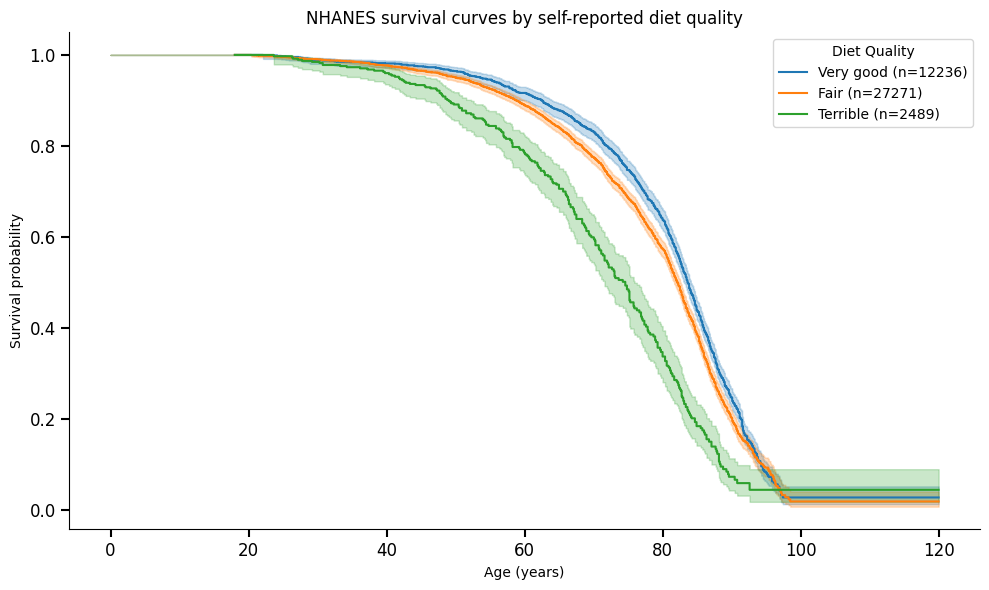

In [30]:

df_diet = core.merge(df.dropna(subset=["diet"]), on="SEQN")

# ---- 4. construct entry/exit/event ----
df_diet["entry_age"] = df_diet["age_in_years"].fillna(df_diet["age_at_screening"]).astype(float)
df_diet["exit_age"] = df_diet["entry_age"] + df_diet["permth_int"] / 12.0
df_diet["event"] = df_diet["mortstat"]

# ---- 5. fit & plot all curves together ----
kmf = KaplanMeierFitter()
ax = None

# Dictionary to store results organized by diet category
diet_results = {}

# Create a timeline with higher resolution to reduce approximation warnings
timeline = np.linspace(0, 120, 1000)

# Diet category labels
diet_labels = {1: "Very good", 2: "Fair", 3: "Terrible"}

fig, ax = plt.subplots(figsize=(10, 6))

# Plot diet groups and calculate steepness and median lifespan
for diet_cat in [1, 2, 3]:
    subset = df_diet[df_diet["diet"] == diet_cat]
    # Filter out rows with NaN entry_age or exit_age
    subset = subset.dropna(subset=["entry_age", "exit_age"])
    print(len(subset))
    if len(subset) == 0:
        print(f"No participants in diet category {diet_cat}")
        continue
    
    # Create label with participant count
    label_with_count = f"{diet_labels[diet_cat]} (n={len(subset)})"
    
    kmf.fit(
        durations=subset["exit_age"],
        event_observed=subset["event"],
        entry=subset["entry_age"],
        label=label_with_count,
        timeline=timeline
    )
    
    kmf.plot_survival_function(ax=ax)
    
    # Calculate steepness and median lifespan for this diet category
    q25 = kmf.percentile(0.25)
    q50 = kmf.percentile(0.5)
    q75 = kmf.percentile(0.75)
    iqr = -(q75 - q25)
    steepness = q50 / iqr if iqr > 0 else np.nan
    diet_results[diet_labels[diet_cat]] = {
        'steepness': steepness,
        'median_lifespan': q50,
        'n_participants': len(subset)
    }

ax.set_xlabel("Age (years)")
ax.set_ylabel("Survival probability")
ax.set_title("NHANES survival curves by self-reported diet quality")
ax.legend(title="Diet Quality")
plt.tight_layout()
plt.show()


# Alcohol

In [13]:
df_A = pd.read_sas('nhanes/alcohol/ALQ.xpt' , format = 'xport')
df_B = pd.read_sas('nhanes/alcohol/ALQ_B.xpt' , format = 'xport')
df_C = pd.read_sas('nhanes/alcohol/ALQ_C.xpt' , format = 'xport')
df_D = pd.read_sas('nhanes/alcohol/ALQ_D.xpt' , format = 'xport')
df_E = pd.read_sas('nhanes/alcohol/ALQ_E.xpt' , format = 'xport')
df_F = pd.read_sas('nhanes/alcohol/ALQ_F.xpt' , format = 'xport')
df_G = pd.read_sas('nhanes/alcohol/ALQ_G.xpt' , format = 'xport')
df_H = pd.read_sas('nhanes/alcohol/ALQ_H.xpt' , format = 'xport')
df_I = pd.read_sas('nhanes/alcohol/ALQ_I.xpt' , format = 'xport')
df_J = pd.read_sas('nhanes/alcohol/ALQ_J.xpt' , format = 'xport')


for df in [df_A, df_B, df_C, df_D, df_E, df_F, df_G, df_H, df_I, df_J]:
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].round().astype('Int64')  # Use nullable integer type to preserve NaN


df = pd.concat([df_A[['SEQN', 'ALQ130']], 
                df_B[['SEQN', 'ALQ130']], 
                df_C[['SEQN', 'ALQ130']], 
                df_D[['SEQN', 'ALQ130']], 
                df_E[['SEQN', 'ALQ130']], 
                df_F[['SEQN', 'ALQ130']], 
                df_G[['SEQN', 'ALQ130']], 
                df_H[['SEQN', 'ALQ130']], 
                df_I[['SEQN', 'ALQ130']], 
                df_J[['SEQN', 'ALQ130']]], axis=0).reset_index(drop=True)


df_alcohol = core.merge(df, on="SEQN")

# Remove rows where ALQ130 has invalid or missing values
df_alcohol = df_alcohol[~df_alcohol['ALQ130'].isin([77, 99, 777, 999, 7777, 9999])]
df_alcohol = df_alcohol.dropna(subset=['ALQ130'])




0-1 drink/day: 11241 participants
2-3 drinks/day: 13257 participants
4-5 drinks/day: 3729 participants
>5 drinks/day: 3625 participants
Baseline median survival time: 82.08333333333333


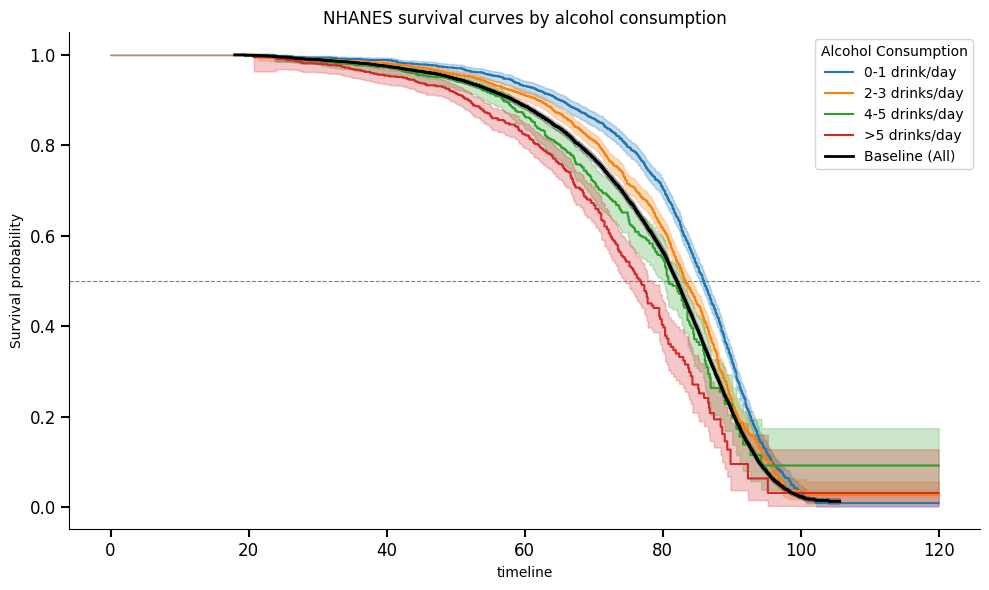


Alcohol Consumption Analysis Results:
0-1 drink/day:
  Participants: 11241
  Median lifespan: 86.0 years
  Steepness: 6.172
2-3 drinks/day:
  Participants: 13257
  Median lifespan: 83.4 years
  Steepness: 5.141
4-5 drinks/day:
  Participants: 3729
  Median lifespan: 80.8 years
  Steepness: 4.006
>5 drinks/day:
  Participants: 3625
  Median lifespan: 76.8 years
  Steepness: 3.781


In [15]:
df_alcohol['ALQ130'].value_counts().sort_index()

# %% cell 9 code

# Create alcohol consumption groups based on ALQ130 (drinks per day)
def categorize_alcohol_consumption(drinks):
    if drinks <= 1:
        return '0-1 drink/day'
    elif drinks <= 3:
        return '2-3 drinks/day'
    elif drinks <= 5:
        return '4-5 drinks/day'
    else:
        return '>5 drinks/day'

df_alcohol['alcohol_group'] = df_alcohol['ALQ130'].apply(categorize_alcohol_consumption)

# ---- 5. fit & plot all curves together ----
kmf = KaplanMeierFitter()

# Create a timeline with higher resolution to reduce approximation warnings
timeline = np.linspace(0, 120, 1000)

fig, ax = plt.subplots(figsize=(10, 6))

# Dictionary to store results organized by alcohol consumption category
alcohol_results = {}

# Plot each alcohol consumption group
for group in ['0-1 drink/day', '2-3 drinks/day', '4-5 drinks/day', '>5 drinks/day']:
    subset = df_alcohol[df_alcohol['alcohol_group'] == group]
    print(f"{group}: {len(subset)} participants")
    
    if len(subset) == 0:
        print(f"No participants in {group}")
        continue
        
    kmf.fit(
        durations=subset["exit_age"],
        event_observed=subset["event"],
        entry=subset["entry_age"],
        label=group,
        timeline=timeline
    )
    
    kmf.plot_survival_function(ax=ax)
    
    # Calculate steepness and median lifespan for this group
    q25 = kmf.percentile(0.25)
    q50 = kmf.percentile(0.5)
    q75 = kmf.percentile(0.75)
    iqr = -(q75 - q25)
    steepness = q50 / iqr if iqr > 0 else np.nan
    alcohol_results[group] = {
        'steepness': steepness,
        'median_lifespan': q50,
        'n_participants': len(subset)
    }

ax.set_xlabel("Age (years)")
ax.set_ylabel("Survival probability")
ax.set_title("NHANES survival curves by alcohol consumption")
kmf = plot_baseline_km(ax)
print(f"Baseline median survival time: {kmf.median_survival_time_}")

ax.legend(title="Alcohol Consumption")
# dotted horizontal line at 0.5
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, zorder=0)

plt.tight_layout()
plt.show()

# Print results summary
print("\nAlcohol Consumption Analysis Results:")
for group, results in alcohol_results.items():
    print(f"{group}:")
    print(f"  Participants: {results['n_participants']}")
    print(f"  Median lifespan: {results['median_lifespan']:.1f} years")
    print(f"  Steepness: {results['steepness']:.3f}")


# Smoking - To Do

In [14]:
df_A = pd.read_sas('nhanes/smoking/SMQ.xpt' , format = 'xport')
df_B = pd.read_sas('nhanes/smoking/SMQ_B.xpt' , format = 'xport')
df_C = pd.read_sas('nhanes/smoking/SMQ_C.xpt' , format = 'xport')
df_D = pd.read_sas('nhanes/smoking/SMQ_D.xpt' , format = 'xport')
df_E = pd.read_sas('nhanes/smoking/SMQ_E.xpt' , format = 'xport')
df_F = pd.read_sas('nhanes/smoking/SMQ_F.xpt' , format = 'xport')
df_G = pd.read_sas('nhanes/smoking/SMQ_G.xpt' , format = 'xport')
df_H = pd.read_sas('nhanes/smoking/SMQ_H.xpt' , format = 'xport')
df_I = pd.read_sas('nhanes/smoking/SMQ_I.xpt' , format = 'xport')
df_J = pd.read_sas('nhanes/smoking/SMQ_J.xpt' , format = 'xport')

# Convert floats to integers (rounded) while preserving NaN values
for df in [df_A, df_B, df_C, df_D, df_E, df_F, df_G, df_H, df_I, df_J]:
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].round().astype('Int64')  # Use nullable integer type to preserve NaN




# %% cell 8 code

# Find common columns across all dataframes
all_dfs = [df_A, df_B, df_C, df_D, df_E, df_F, df_G, df_H, df_I, df_J]
common_columns = set(df_A.columns)
for df in all_dfs[1:]:
    common_columns = common_columns.intersection(set(df.columns))

# Keep only common columns in each dataframe and combine them
smoking_parts = []
for df in all_dfs:
    smoking_parts.append(df[list(common_columns)])

# Combine all dataframes
smoking = pd.concat(smoking_parts, ignore_index=True)
# organize columns alphabetically in smoking
smoking = smoking.reindex(sorted(smoking.columns), axis=1)



In [15]:
smoking

,SEQN,SMD030,SMD057,SMD100BR,SMD100CO,SMD100FL,SMD100LN,SMD100MN,SMD100NI,SMD100TR,SMQ020,SMQ040,SMQ050Q,SMQ050U
0,2,<NA>,<NA>,b'',<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2,<NA>,<NA>,<NA>
1,5,0,<NA>,b'',<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,3,5,3
2,7,17,20,b'',<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,3,20,4
3,10,16,<NA>,b'NEWPORT',17,1,85,1,1,17,1,1,<NA>,<NA>
4,12,<NA>,<NA>,b'',<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64869,102952,<NA>,<NA>,b'',<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2,<NA>,<NA>,<NA>
64870,102953,20,1,b'',<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,3,9,3
64871,102954,<NA>,<NA>,b'',<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2,<NA>,<NA>,<NA>
64872,102955,<NA>,<NA>,b'',<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


# Income

In [3]:
df_E = pd.read_sas('nhanes/income/INQ_E.xpt' , format = 'xport')
df_F = pd.read_sas('nhanes/income/INQ_F.xpt' , format = 'xport')
df_G = pd.read_sas('nhanes/income/INQ_G.xpt' , format = 'xport')
df_H = pd.read_sas('nhanes/income/INQ_H.xpt' , format = 'xport')
df_I = pd.read_sas('nhanes/income/INQ_I.xpt' , format = 'xport')
df_J = pd.read_sas('nhanes/income/INQ_J.xpt' , format = 'xport')

# Convert floats to integers (rounded) while preserving NaN values
for df in [df_E, df_F, df_G, df_H, df_I, df_J]:
    for col in df.columns:
        if df[col].dtype == 'float64' and col not in ['INDFMMPI', 'INDFMMPC']:
            df[col] = df[col].round().astype('Int64')  # Use nullable integer type to preserve NaN

# Filter out rows where INDFMMPI is not NA


# Combine all diet dataframes keeping only SEQN and DBQ700 columns
df = pd.concat([
    df_E[['SEQN', 'INDFMMPI' , 'INDFMMPC']], 
    df_F[['SEQN', 'INDFMMPI' , 'INDFMMPC']],
    df_G[['SEQN', 'INDFMMPI' , 'INDFMMPC']],
    df_H[['SEQN', 'INDFMMPI' , 'INDFMMPC']],
    df_I[['SEQN', 'INDFMMPI' , 'INDFMMPC']],
    df_J[['SEQN', 'INDFMMPI']]
], axis=0).reset_index(drop=True)

# Create diet column based on DBQ700 values


df_income = core.merge(df , on="SEQN")





/var/folders/r5/2q8zzrr15ld3_jcs6mjrvk900000gn/T/ipykernel_21266/3239894984.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_income_clean["poverty_quartile"] = quartiles


Quartile 1: 7897 participants
Quartile 2: 7770 participants
Quartile 3: 7783 participants
Quartile 4: 7784 participants
82.08333333333333


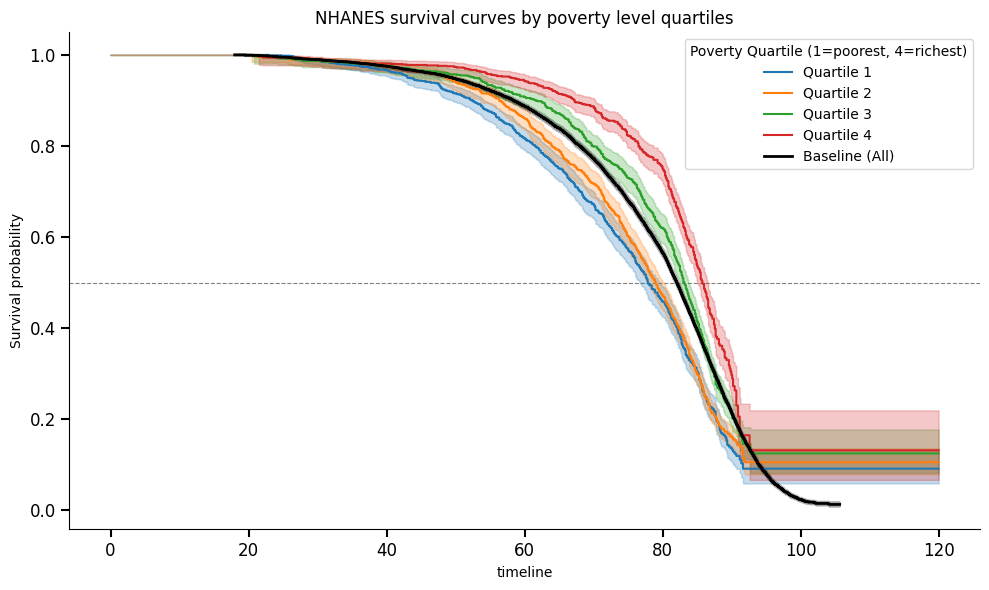

In [4]:



# ---- 5. fit & plot all curves together ----
kmf = KaplanMeierFitter()
ax = None

# Dictionary to store results organized by diet category
diet_results = {}

# Create a timeline with higher resolution to reduce approximation warnings
timeline = np.linspace(0, 120, 1000)

# Diet category labels

fig, ax = plt.subplots(figsize=(10, 6))
# Define quartiles based on INDFMMPI value
df_income_clean = df_income.dropna(subset=["INDFMMPI", "entry_age", "exit_age"])


quartiles = pd.qcut(df_income_clean["INDFMMPI"], q=4, labels=[1, 2, 3, 4])
df_income_clean["poverty_quartile"] = quartiles

# Dictionary to store results organized by quartile
quartile_results = {}

# Plot quartiles and calculate steepness and median lifespan
for quartile in [1, 2, 3, 4]:
    subset = df_income_clean[df_income_clean["poverty_quartile"] == quartile]
    print(f"Quartile {quartile}: {len(subset)} participants")
    
    if len(subset) == 0:
        print(f"No participants in quartile {quartile}")
        continue
        
    kmf.fit(
        durations=subset["exit_age"],
        event_observed=subset["event"],
        entry=subset["entry_age"],
        label=f"Quartile {quartile}",
        timeline=timeline
    )
    
    kmf.plot_survival_function(ax=ax)
    
    # Calculate steepness and median lifespan for this quartile
    q25 = kmf.percentile(0.25)
    q50 = kmf.percentile(0.5)
    q75 = kmf.percentile(0.75)
    iqr = -(q75 - q25)
    steepness = q50 / iqr if iqr > 0 else np.nan
    quartile_results[f"Quartile {quartile}"] = {
        'steepness': steepness,
        'median_lifespan': q50,
        'n_participants': len(subset)
    }

ax.set_xlabel("Age (years)")
ax.set_ylabel("Survival probability")
ax.set_title("NHANES survival curves by poverty level quartiles")
kmf = plot_baseline_km(ax)
print(kmf.median_survival_time_)

ax.legend(title="Poverty Quartile (1=poorest, 4=richest)")
# dotted horizontal line at 0.5
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, zorder=0)


plt.tight_layout()
plt.show()



Poverty: 8145 participants
Upper-middle class: 6156 participants
82.08333333333333


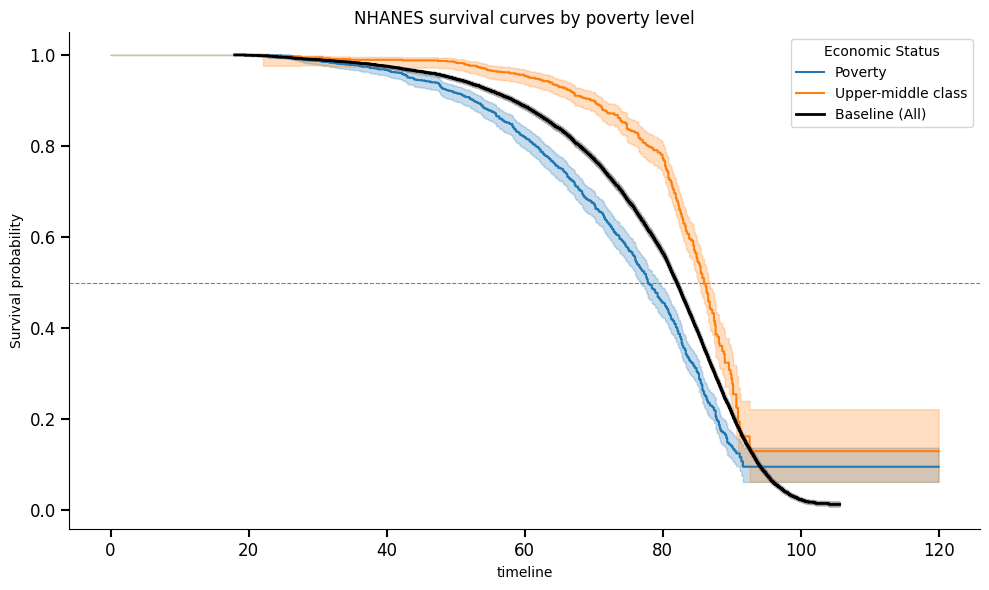

In [5]:



# ---- 5. fit & plot all curves together ----
kmf = KaplanMeierFitter()
ax = None

# Dictionary to store results organized by poverty groups
poverty_results = {}

# Create a timeline with higher resolution to reduce approximation warnings
timeline = np.linspace(0, 120, 1000)

# Poverty group labels

fig, ax = plt.subplots(figsize=(10, 6))
# Define poverty groups based on INDFMMPI value
df_income_clean = df_income.dropna(subset=["INDFMMPI", "entry_age", "exit_age"])

# Create poverty groups: <= 1 (poverty) and >= 4 (upper-middle class)
df_income_clean = df_income_clean[
    (df_income_clean["INDFMMPI"] <= 1) | (df_income_clean["INDFMMPI"] >= 4)
]

df_income_clean["poverty_group"] = df_income_clean["INDFMMPI"].apply(
    lambda x: "Poverty" if x <= 1 else "Upper-middle class"
)

# Dictionary to store results organized by poverty group
poverty_results = {}

# Plot poverty groups and calculate steepness and median lifespan
for group in ["Poverty", "Upper-middle class"]:
    subset = df_income_clean[df_income_clean["poverty_group"] == group]
    print(f"{group}: {len(subset)} participants")
    
    if len(subset) == 0:
        print(f"No participants in {group}")
        continue
        
    kmf.fit(
        durations=subset["exit_age"],
        event_observed=subset["event"],
        entry=subset["entry_age"],
        label=f"{group}",
        timeline=timeline
    )
    
    kmf.plot_survival_function(ax=ax)
    
    # Calculate steepness and median lifespan for this group
    q25 = kmf.percentile(0.25)
    q50 = kmf.percentile(0.5)
    q75 = kmf.percentile(0.75)
    iqr = -(q75 - q25)
    steepness = q50 / iqr if iqr > 0 else np.nan
    poverty_results[group] = {
        'steepness': steepness,
        'median_lifespan': q50,
        'n_participants': len(subset)
    }

ax.set_xlabel("Age (years)")
ax.set_ylabel("Survival probability")
ax.set_title("NHANES survival curves by poverty level")
kmf = plot_baseline_km(ax)
print(kmf.median_survival_time_)

ax.legend(title="Economic Status")
# dotted horizontal line at 0.5
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, zorder=0)


plt.tight_layout()
plt.show()


# Sexual Frequency - Insufficient

In [60]:

df_D = pd.read_sas('nhanes/sex/SXQ_D.xpt' , format = 'xport')
df_E = pd.read_sas('nhanes/sex/SXQ_E.xpt' , format = 'xport')
df_F = pd.read_sas('nhanes/sex/SXQ_F.xpt' , format = 'xport')
df_G = pd.read_sas('nhanes/sex/SXQ_G.xpt' , format = 'xport')
df_H = pd.read_sas('nhanes/sex/SXQ_H.xpt' , format = 'xport')
df_I = pd.read_sas('nhanes/sex/SXQ_I.xpt' , format = 'xport')

# Convert floats to integers (rounded) while preserving NaN values
for df in [df_D, df_E, df_F, df_G, df_H, df_I]:
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].round().astype('Int64')  # Use nullable integer type to preserve NaN

# Filter out rows where INDFMMPI is not NA



# Combine all diet dataframes keeping only SEQN and DBQ700 columns
df = pd.concat([
    df_D[['SEQN', 'SXQ610']],
    df_E[['SEQN', 'SXQ610']],
    df_F[['SEQN', 'SXQ610']],
    df_G[['SEQN', 'SXQ610']],
    df_I[['SEQN', 'SXQ610']],
], axis=0).reset_index(drop=True)

# Create diet column based on DBQ700 values







Intercourse frequency Low: 4252 people
Intercourse frequency Medium: 7155 people
Intercourse frequency High: 2118 people


/var/folders/r5/2q8zzrr15ld3_jcs6mjrvk900000gn/T/ipykernel_61217/400782305.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sex_clean["intercourse_frequency"] = df_sex_clean["SXQ610"].apply(categorize_intercourse_frequency)


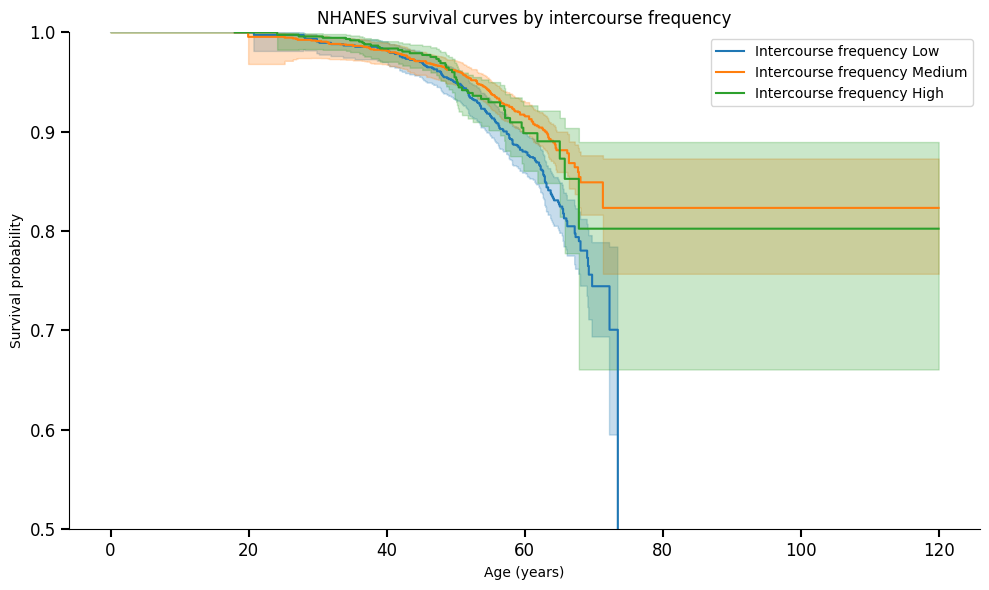

In [64]:


# ---- 2. filter mortality data ----
mort = mort[mort["eligstat"] == 1]  # keep only linkage-eligible

# ---- 3. merge all data ----
core = age.merge(mort, on="SEQN")
df_sex = core.merge(df , on="SEQN")

# ---- 4. construct entry/exit/event ----
df_sex["entry_age"] = df_sex["age_at_screening"].astype(float)
df_sex["exit_age"] = df_sex["entry_age"] + df_sex["permth_int"] / 12.0
df_sex["event"] = df_sex["mortstat"]


# ---- 5. fit & plot all curves together ----
kmf = KaplanMeierFitter()
ax = None

# Dictionary to store results organized by diet category
diet_results = {}

# Create a timeline with higher resolution to reduce approximation warnings
timeline = np.linspace(0, 120, 1000)

# Diet category labels

fig, ax = plt.subplots(figsize=(10, 6))
# Define quartiles based on INDFMMPI value
# Create intercourse frequency column based on SXQ610 values
def categorize_intercourse_frequency(sxq610_value):
    if pd.isna(sxq610_value):
        return None
    elif sxq610_value in [0, 1, 2]:
        return "Low"
    elif sxq610_value in [3, 4]:
        return "Medium"
    elif sxq610_value in [5, 6]:
        return "High"
    else:
        return None

df_sex_clean = df_sex.dropna(subset=["SXQ610", "entry_age", "exit_age"])
df_sex_clean["intercourse_frequency"] = df_sex_clean["SXQ610"].apply(categorize_intercourse_frequency)

# Dictionary to store results organized by intercourse frequency
frequency_results = {}

# Plot intercourse frequency groups and calculate steepness and median lifespan
for freq_group in ["Low", "Medium", "High"]:
    subset = df_sex_clean[df_sex_clean["intercourse_frequency"] == freq_group]
    print(f"Intercourse frequency {freq_group}: {len(subset)} people")
    
    if len(subset) == 0:
        print(f"No participants in group {freq_group}")
        continue
        
    kmf.fit(
        durations=subset["exit_age"],
        event_observed=subset["event"],
        entry=subset["entry_age"],
        label=f"Intercourse frequency {freq_group}",
        timeline=timeline
    )
    
    kmf.plot_survival_function(ax=ax)
    
    # Calculate steepness and median lifespan for this frequency group
    q25 = kmf.percentile(0.25)
    q50 = kmf.percentile(0.5)
    q75 = kmf.percentile(0.75)
    iqr = -(q75 - q25)
    steepness = q50 / iqr if iqr > 0 else np.nan
    frequency_results[f"{freq_group}"] = {
        'steepness': steepness,
        'median_lifespan': q50,
        'n_participants': len(subset)
    }

ax.set_xlabel("Age (years)")
ax.set_ylabel("Survival probability")
ax.set_title("NHANES survival curves by intercourse frequency")
ax.legend(title="")
plt.tight_layout()
plt.ylim(0.5, 1)
plt.show()




not enough old people

# Social Support

In [3]:
df_A = pd.read_sas('nhanes/social_support/SSQ.xpt' , format = 'xport')
df_B = pd.read_sas('nhanes/social_support/SSQ_B.xpt' , format = 'xport')
df_C = pd.read_sas('nhanes/social_support/SSQ_C.xpt' , format = 'xport')
df_D = pd.read_sas('nhanes/social_support/SSQ_D.xpt' , format = 'xport')
df_E = pd.read_sas('nhanes/social_support/SSQ_E.xpt' , format = 'xport')

# Convert floats to integers (rounded) while preserving NaN values
for df in [df_A, df_B, df_C, df_D, df_E]:
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].round().astype('Int64')  # Use nullable integer type to preserve NaN

# Filter out rows where INDFMMPI is not NA


# Combine all social support dataframes with standardized column names
df_social_support = pd.concat([
    df_A[['SEQN', 'SSQ030', 'SSQ060']].rename(columns={'SSQ030': 'need_support', 'SSQ060': 'number_of_friends'}),
    df_B[['SEQN', 'SSD031', 'SSD061']].rename(columns={'SSD031': 'need_support', 'SSD061': 'number_of_friends'}),
    df_C[['SEQN', 'SSQ031', 'SSQ061']].rename(columns={'SSQ031': 'need_support', 'SSQ061': 'number_of_friends'}),
    df_D[['SEQN', 'SSQ031', 'SSQ061']].rename(columns={'SSQ031': 'need_support', 'SSQ061': 'number_of_friends'}),
    df_E[['SEQN', 'SSQ031', 'SSQ061']].rename(columns={'SSQ031': 'need_support', 'SSQ061': 'number_of_friends'}),
], axis=0).reset_index(drop=True)

# Filter out rows with invalid number_of_friends values
df_social_support = df_social_support[~df_social_support['number_of_friends'].isin([7777, 9999])]

df_social_support_merged = core.merge(df_social_support, on="SEQN")




Support need 1: 2394 people
Support need 2: 10250 people
Friends category 0 friends: 637 people
Friends category 1-5 friends: 7696 people
Friends category 6-10 friends: 3598 people
Friends category >10 friends: 1986 people


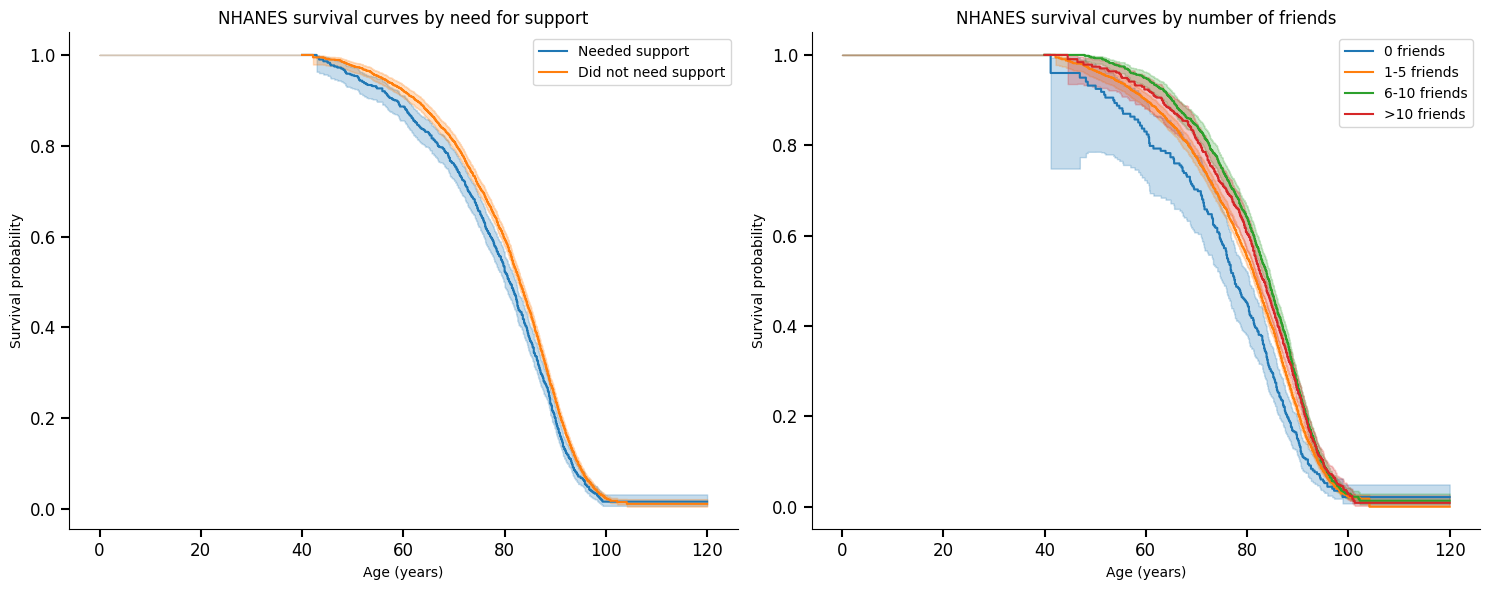

In [4]:

# ---- 5. fit & plot all curves together ----
kmf = KaplanMeierFitter()

# Create a timeline with higher resolution to reduce approximation warnings
timeline = np.linspace(0, 120, 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left plot: Social support need
df_support_clean = df_social_support_merged.dropna(subset=["need_support", "entry_age", "exit_age"])

for support_level in [1, 2]:
    subset = df_support_clean[df_support_clean["need_support"] == support_level]
    support_label = "Needed support" if support_level == 1 else "Did not need support"
    print(f"Support need {support_level}: {len(subset)} people")
    
    if len(subset) == 0:
        print(f"No participants in support group {support_level}")
        continue
        
    kmf.fit(
        durations=subset["exit_age"],
        event_observed=subset["event"],
        entry=subset["entry_age"],
        label=support_label,
        timeline=timeline
    )
    
    kmf.plot_survival_function(ax=ax1)

ax1.set_xlabel("Age (years)")
ax1.set_ylabel("Survival probability")
ax1.set_title("NHANES survival curves by need for support")
ax1.legend(title="")

# Right plot: Number of friends quartiles
df_friends_clean = df_social_support_merged.dropna(subset=["number_of_friends", "entry_age", "exit_age"])

# Toggle between partitioning strategies
use_quartiles = False  # Set to True for quartiles, False for custom bins

if use_quartiles:
    # Define quartiles for number of friends
    quartiles = pd.qcut(df_friends_clean["number_of_friends"], q=4, labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"])
    df_friends_clean = df_friends_clean.copy()
    df_friends_clean["friends_quartile"] = quartiles
    
    for quartile in ["Q1 (Low)", "Q2", "Q3", "Q4 (High)"]:
        subset = df_friends_clean[df_friends_clean["friends_quartile"] == quartile]
        print(f"Friends quartile {quartile}: {len(subset)} people")
        
        if len(subset) == 0:
            print(f"No participants in quartile {quartile}")
            continue
            
        kmf.fit(
            durations=subset["exit_age"],
            event_observed=subset["event"],
            entry=subset["entry_age"],
            label=f"Friends {quartile}",
            timeline=timeline
        )
        
        kmf.plot_survival_function(ax=ax2)
else:
    # Define custom bins for number of friends
    def categorize_friends(num_friends):
        if num_friends == 0:
            return "0 friends"
        elif 1 <= num_friends <= 5:
            return "1-5 friends"
        elif 6 <= num_friends <= 10:
            return "6-10 friends"
        else:
            return ">10 friends"
    
    df_friends_clean = df_friends_clean.copy()
    df_friends_clean["friends_category"] = df_friends_clean["number_of_friends"].apply(categorize_friends)
    
    for category in ["0 friends", "1-5 friends", "6-10 friends", ">10 friends"]:
        subset = df_friends_clean[df_friends_clean["friends_category"] == category]
        print(f"Friends category {category}: {len(subset)} people")
        
        if len(subset) == 0:
            print(f"No participants in category {category}")
            continue
            
        kmf.fit(
            durations=subset["exit_age"],
            event_observed=subset["event"],
            entry=subset["entry_age"],
            label=category,
            timeline=timeline
        )
        
        kmf.plot_survival_function(ax=ax2)

ax2.set_xlabel("Age (years)")
ax2.set_ylabel("Survival probability")
ax2.set_title("NHANES survival curves by number of friends")
ax2.legend(title="")

plt.tight_layout()
plt.show()



# Regularity of Work

In [24]:

df_D = pd.read_sas('nhanes/occupation/OCQ_D.xpt' , format = 'xport')
df_E = pd.read_sas('nhanes/occupation/OCQ_E.xpt' , format = 'xport')
df_F = pd.read_sas('nhanes/occupation/OCQ_F.xpt' , format = 'xport')

# Convert floats to integers (rounded) while preserving NaN values
for df in [df_D, df_E , df_F , df_G , df_H , df_I, df_J]:
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].round().astype('Int64')  # Use nullable integer type to preserve NaN

# Filter out rows where INDFMMPI is not NA


# Combine all social support dataframes with standardized column names
df_work_hours = pd.concat([
    df_D[['SEQN', 'OCQ265']].rename(columns={'OCQ265': 'work_hours'}),
    df_E[['SEQN', 'OCQ265']].rename(columns={'OCQ265': 'work_hours'}),
    df_F[['SEQN', 'OCQ265']].rename(columns={'OCQ265': 'work_hours'})
], axis=0).reset_index(drop=True)

df_work_hours_merged = core.merge(df_work_hours, on="SEQN")




Daytime work: 7227 people
Night shift: 1051 people
Rotating shift: 1712 people


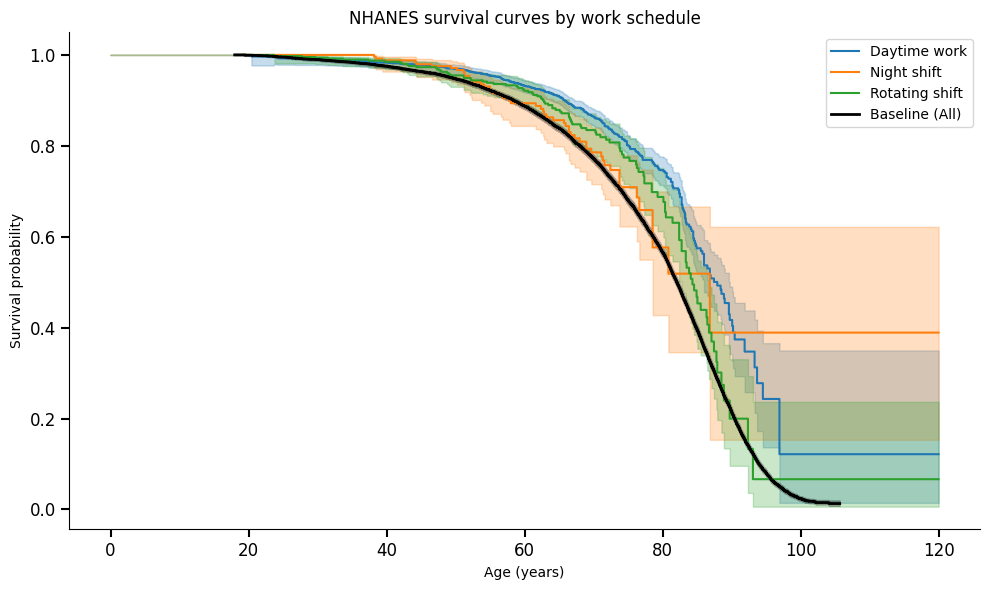

In [26]:




kmf = KaplanMeierFitter()

# Create a timeline with higher resolution to reduce approximation warnings
timeline = np.linspace(0, 120, 1000)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Clean data and create work schedule categories
df_work_clean = df_work_hours_merged.dropna(subset=["work_hours", "entry_age", "exit_age"])

# Define work schedule categories
def categorize_work_schedule(work_hours):
    if work_hours == 1:
        return "Daytime work"
    elif work_hours in [2, 3]:
        return "Night shift"
    elif work_hours in [4, 5]:
        return "Rotating shift"
    else:
        return None

df_work_clean = df_work_clean.copy()
df_work_clean["work_schedule"] = df_work_clean["work_hours"].apply(categorize_work_schedule)

# Remove rows where work schedule couldn't be categorized
df_work_clean = df_work_clean.dropna(subset=["work_schedule"])

for schedule in ["Daytime work", "Night shift", "Rotating shift"]:
    subset = df_work_clean[df_work_clean["work_schedule"] == schedule]
    print(f"{schedule}: {len(subset)} people")
    
    if len(subset) == 0:
        print(f"No participants in {schedule} group")
        continue
        
    kmf.fit(
        durations=subset["exit_age"],
        event_observed=subset["event"],
        entry=subset["entry_age"],
        label=schedule,
        timeline=timeline
    )
    
    kmf.plot_survival_function(ax=ax)

kmf = plot_baseline_km(ax)

ax.set_xlabel("Age (years)")
ax.set_ylabel("Survival probability")
ax.set_title("NHANES survival curves by work schedule")
ax.legend(title="")

plt.tight_layout()
plt.show()


Value counts for church_frequency:
church_frequency_group
never        2415
weekly       1890
sometimes    1882
Name: count, dtype: int64


<Axes: title={'center': 'Survival by Church Attendance Frequency'}, xlabel='Age (years)', ylabel='Survival Probability'>

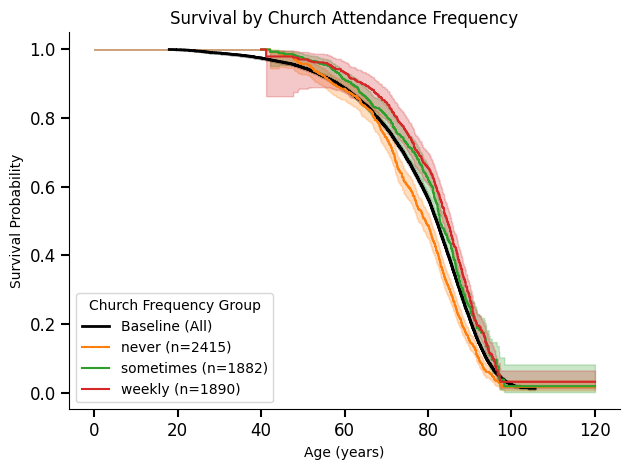

In [5]:
fig, ax = plt.subplots()
nhanes.plot_survival_by_topic(topic_name = "church_frequency", ax=ax)


# Sleep Duration

In [34]:
df_D = pd.read_sas('nhanes/sleep/SLQ_D.xpt' , format = 'xport')
df_E = pd.read_sas('nhanes/sleep/SLQ_E.xpt' , format = 'xport')
df_F = pd.read_sas('nhanes/sleep/SLQ_F.xpt' , format = 'xport')
df_G = pd.read_sas('nhanes/sleep/SLQ_G.xpt' , format = 'xport')
df_H = pd.read_sas('nhanes/sleep/SLQ_H.xpt' , format = 'xport')
df_I = pd.read_sas('nhanes/sleep/SLQ_I.xpt' , format = 'xport')
df_J = pd.read_sas('nhanes/sleep/SLQ_J.xpt' , format = 'xport')

# Convert floats to integers (rounded) while preserving NaN values
for df in [df_D, df_E, df_F, df_G, df_H, df_I, df_J]:
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].round().astype('Int64')  # Use nullable integer type to preserve NaN


# Combine all social support dataframes with standardized column names
df_sleep = pd.concat([
    df_D[['SEQN', 'SLD010H']].rename(columns={'SLD010H': 'sleep_hours'}),
    df_E[['SEQN', 'SLD010H']].rename(columns={'SLD010H': 'sleep_hours'}),
    df_F[['SEQN', 'SLD010H']].rename(columns={'SLD010H': 'sleep_hours'}),
    df_G[['SEQN', 'SLD010H']].rename(columns={'SLD010H': 'sleep_hours'}),
    df_H[['SEQN', 'SLD010H']].rename(columns={'SLD010H': 'sleep_hours'}),
    df_I[['SEQN', 'SLD012']].rename(columns={'SLD012': 'sleep_hours'}),
    df_J[['SEQN', 'SLD012']].rename(columns={'SLD012': 'sleep_hours'})
], axis=0).reset_index(drop=True)



df_sleep_merged = core.merge(df_sleep, on="SEQN")




Unique sleep hours values:
sleep_hours
1        19
2       119
3       380
4      1611
5      3423
6      9350
7     10367
8     13441
9      3192
10     1852
11      382
12      364
13       36
14       23
77        2
99       40
Name: count, dtype: Int64
<5 hours sleep: 2092 people
5-<7 hours sleep: 12255 people
7-<9 hours sleep: 22189 people
≥9 hours sleep: 5389 people


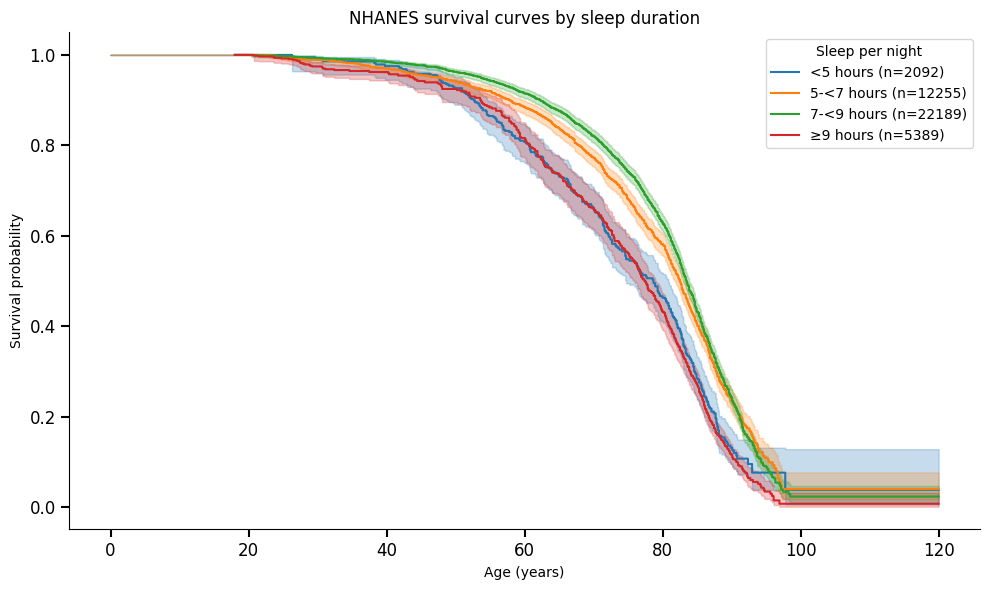

In [ ]:
# Get unique sleep_hours values for debugging
print("Unique sleep hours values:")
print(df_sleep['sleep_hours'].value_counts().sort_index())

# ---- 5. fit & plot sleep duration curves ----
kmf = KaplanMeierFitter()

# Create a timeline with higher resolution to reduce approximation warnings
timeline = np.linspace(0, 120, 1000)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Clean data and create sleep groups
df_sleep_clean = df_sleep_merged.dropna(subset=["sleep_hours", "entry_age", "exit_age"])

# Create different sleep duration groups
group1 = df_sleep_clean[(df_sleep_clean["sleep_hours"] >= 1) & (df_sleep_clean["sleep_hours"] < 5)]
group2 = df_sleep_clean[(df_sleep_clean["sleep_hours"] >= 5) & (df_sleep_clean["sleep_hours"] < 7)]
group3 = df_sleep_clean[(df_sleep_clean["sleep_hours"] >= 7) & (df_sleep_clean["sleep_hours"] < 9)]
group4 = df_sleep_clean[df_sleep_clean["sleep_hours"] >= 9]

print(f"<5 hours sleep: {len(group1)} people")
print(f"5-<7 hours sleep: {len(group2)} people")
print(f"7-<9 hours sleep: {len(group3)} people")
print(f"≥9 hours sleep: {len(group4)} people")

# Plot group 1 (<5 hours)
if len(group1) > 0:
    kmf.fit(
        durations=group1["exit_age"],
        event_observed=group1["event"],
        entry=group1["entry_age"],
        label=f"<5 hours (n={len(group1)})",
        timeline=timeline
    )
    
    kmf.plot_survival_function(ax=ax)

# Plot group 2 (5-<7 hours)
if len(group2) > 0:
    kmf.fit(
        durations=group2["exit_age"],
        event_observed=group2["event"],
        entry=group2["entry_age"],
        label=f"5-<7 hours (n={len(group2)})",
        timeline=timeline
    )
    
    kmf.plot_survival_function(ax=ax)

# Plot group 3 (7-<9 hours)
if len(group3) > 0:
    kmf.fit(
        durations=group3["exit_age"],
        event_observed=group3["event"],
        entry=group3["entry_age"],
        label=f"7-<9 hours (n={len(group3)})",
        timeline=timeline
    )
    
    kmf.plot_survival_function(ax=ax)

# Plot group 4 (≥9 hours)
if len(group4) > 0:
    kmf.fit(
        durations=group4["exit_age"],
        event_observed=group4["event"],
        entry=group4["entry_age"],
        label=f"≥9 hours (n={len(group4)})",
        timeline=timeline
    )
    
    kmf.plot_survival_function(ax=ax)

ax.set_xlabel("Age (years)")
ax.set_ylabel("Survival probability")
ax.set_title("NHANES survival curves by sleep duration")
ax.legend(title="Sleep per night")

plt.tight_layout()
plt.show()


Value counts for sleep_duration:
sleep_hours_group
7-<9 hours    22189
5-<7 hours    12255
≥9 hours       5389
1-<5 hours     2092
Name: count, dtype: int64


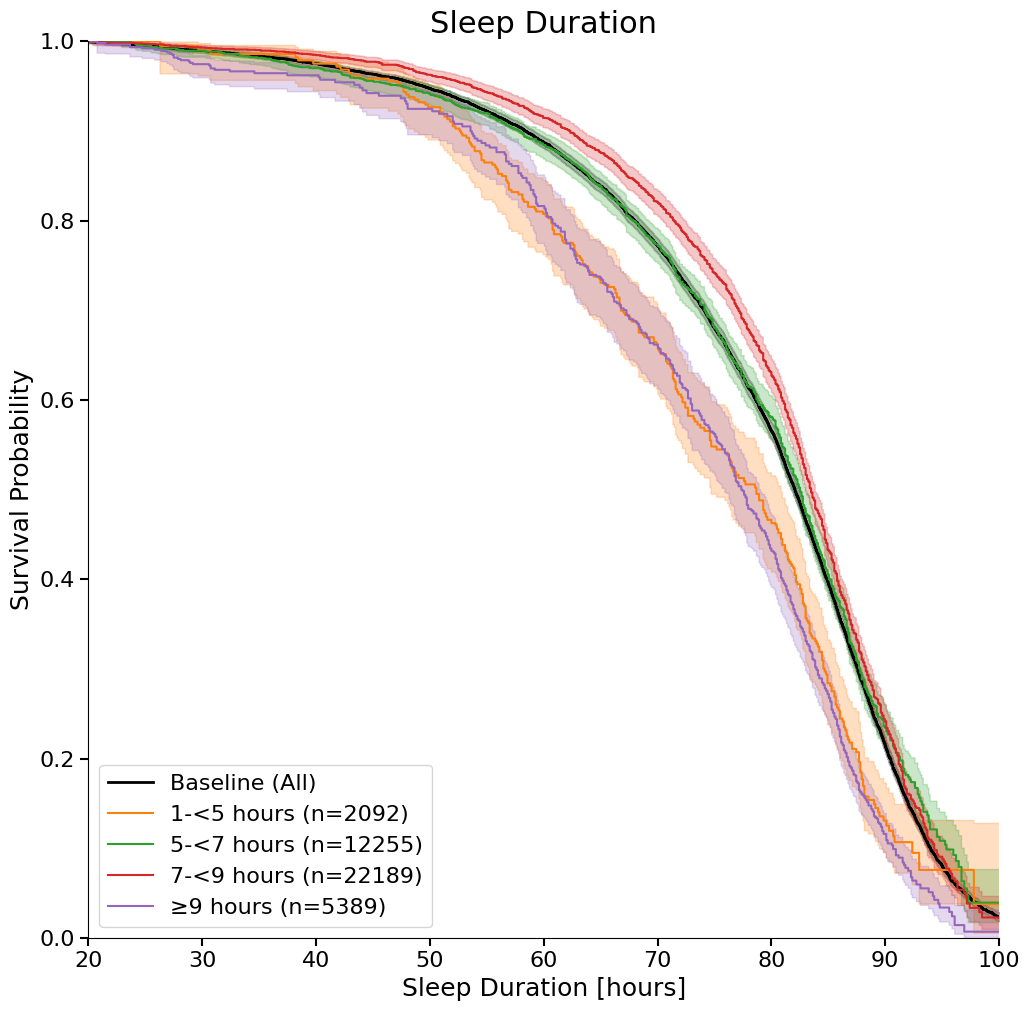

In [3]:
fig, ax = plt.subplots(1, 1, figsize = (10, 10))
nhanes.plot_survival_by_topic(topic_name='sleep_duration', with_extrinsic=True, ax = ax)
ax.set_xlim(20, 100)
ax.set_ylim(0, 1)
ax.set_title('Sleep Duration', fontsize = 22)
ax.set_xlabel('Sleep Duration [hours]', fontsize = 18)
ax.set_ylabel('Survival Probability', fontsize = 18)
ax.tick_params(labelsize = 16)
ax.legend(fontsize = 16)
ax.grid(False)


Fitted to KMF data:
a:  5.053198708588855e-05
b:  0.08875046646762041
c:  8.999408204926322
m:  3.901236639085551e-09
Final MSE: 0.000317
Optimization success: True
Fitted to KMF data:
a:  5.053198708588855e-05
b:  0.08875046646762041
c:  8.999408204926322
m:  3.901236639085551e-09
Final MSE: 0.000317
Optimization success: True


<lifelines.KaplanMeierFitter:"Baseline (All)", fitted with 59064 total observations, 49815 right-censored observations>

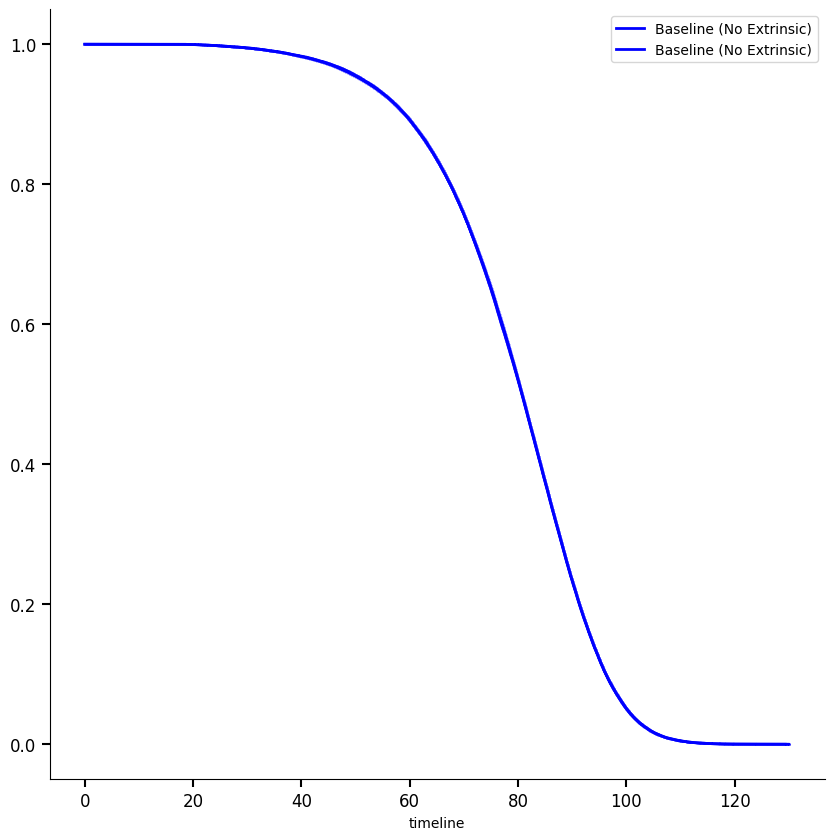

In [8]:
fig, ax = plt.subplots(1, 1, figsize = (10, 10))
nhanes.plot_baseline_km(mgg_fit=True, zero_m = True, ax = ax)
nhanes.plot_baseline_km(mgg_fit=True, zero_m = False, ax = ax)


# Sleep Quality

In [5]:
# only these two include comprehensive questions on sleep quality
df_D = pd.read_sas('nhanes/sleep/SLQ_D.xpt' , format = 'xport')
df_E = pd.read_sas('nhanes/sleep/SLQ_E.xpt' , format = 'xport')


# Convert floats to integers (rounded) while preserving NaN values
for df in [df_D, df_E]:
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].round().astype('Int64')  # Use nullable integer type to preserve NaN




# Combine all social support dataframes with standardized column names
df_sleep = pd.concat([
    df_D,
    df_E
], axis=0).reset_index(drop=True)


df_sleep_merged = core.merge(df_sleep, on="SEQN")



preprocessing

In [6]:
df_sleep_merged = df_sleep_merged.dropna(subset=['years_remaining'])
df_sleep_merged = df_sleep_merged.dropna(subset=['SLD010H'])
# round years_remaining column to the nearest integer
df_sleep_merged['years_remaining'] = df_sleep_merged['years_remaining'].round()

def fill_vals(df, column_name, exclude_values):
    # Exclude rows with specified values
    valid_data = df[~df[column_name].isin(exclude_values)]

    # Calculate the median
    median_value = valid_data[column_name].median()

    # Replace specified values with the median
    df[column_name] = df[column_name].replace({val: median_value for val in exclude_values})

    return df

for col in ['SLQ050', 'SLQ060']:
    df_sleep_merged[col].fillna(0, inplace=True)

for col in ['SLQ070A', 'SLQ070B', 'SLQ070C', 'SLQ070D']:
    df_sleep_merged[col].fillna(0, inplace=True)

for col in ['SLD010H', 'SLD020M']:
    df_sleep_merged = fill_vals(df_sleep_merged, col, [77, 99])

for col in ['SLQ030', 'SLQ040', 'SLQ050', 'SLQ060', 'SLQ070A', 'SLQ080', 'SLQ090', 'SLQ100', 'SLQ110', 'SLQ120', 'SLQ130', 'SLQ140', 'SLQ150', 'SLQ160']:
    df_sleep_merged = fill_vals(df_sleep_merged, col, [7, 9])

for col in ['SLQ170', 'SLQ180', 'SLQ190', 'SLQ200', 'SLQ210', 'SLQ220', 'SLQ230', 'SLQ240']:
    df_sleep_merged = fill_vals(df_sleep_merged, col, [1, 7, 9])

/var/folders/r5/2q8zzrr15ld3_jcs6mjrvk900000gn/T/ipykernel_22144/3074046717.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_sleep_merged[col].fillna(0, inplace=True)
/var/folders/r5/2q8zzrr15ld3_jcs6mjrvk900000gn/T/ipykernel_22144/3074046717.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

scaling, from 0 to 1, defining frailty index

In [7]:
# Initialize the StandardScaler
standard_scaler = skp.StandardScaler()

df_sleep_merged.SLD010H = abs(standard_scaler.fit_transform(df_sleep_merged[['SLD010H']]))

# Select columns with 'SLQ' and 'SLD' in their names
columns_to_scale = [col for col in df_sleep_merged.columns if 'SLQ' in col or 'SLD' in col]

# Initialize the MinMaxScaler
min_max_scaler = skp.MinMaxScaler()

# Fit and transform the selected columns
df_sleep_merged[columns_to_scale] = min_max_scaler.fit_transform(df_sleep_merged[columns_to_scale])

# Create a new column called sleep_frailty that averages the values of the columns with 'SLQ' and 'SLD' in their names
df_sleep_merged['sleep_frailty'] = df_sleep_merged[columns_to_scale].mean(axis=1)

Quartile 1: 2948 people
Quartile 2: 2972 people
Quartile 3: 2923 people
Quartile 4: 2937 people


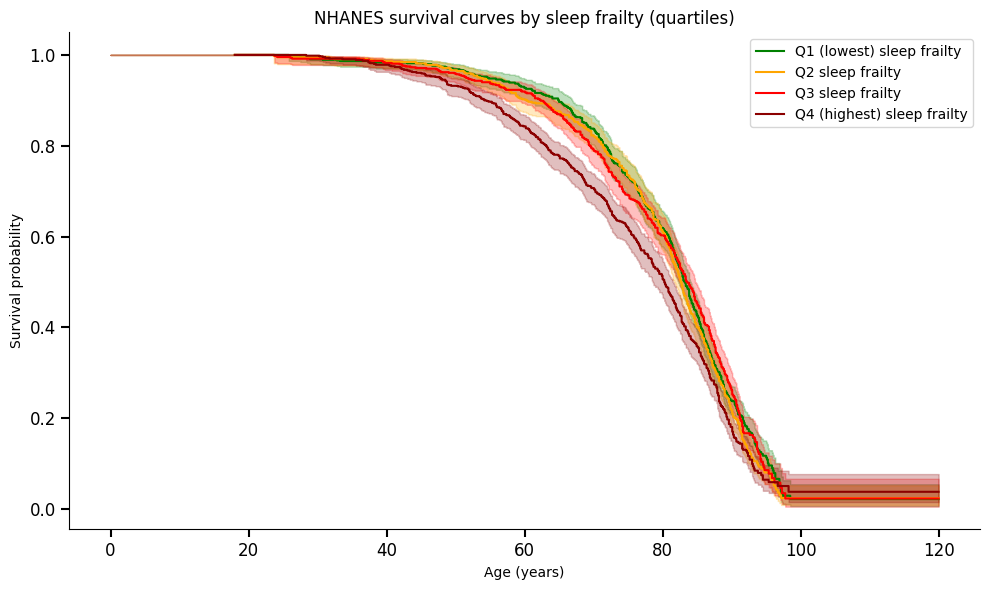

In [8]:

# ---- 5. fit & plot sleep frailty curves ----
kmf = KaplanMeierFitter()

# Create a timeline with higher resolution to reduce approximation warnings
timeline = np.linspace(0, 120, 1000)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Clean data and create sleep frailty quartiles
df_sleep_clean = df_sleep_merged.dropna(subset=["sleep_frailty", "entry_age", "exit_age"])

# Create quartiles for sleep_frailty
quartiles = pd.qcut(df_sleep_clean["sleep_frailty"], q=4, labels=False, duplicates='drop')
df_sleep_clean = df_sleep_clean.copy()
df_sleep_clean["sleep_frailty_quartile"] = quartiles

# Define colors for each quartile
colors = ['green', 'orange', 'red', 'darkred']
quartile_labels = ['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)']

# Plot each quartile
for q in range(4):
    quartile_data = df_sleep_clean[df_sleep_clean["sleep_frailty_quartile"] == q]
    
    if len(quartile_data) > 0:
        print(f"Quartile {q+1}: {len(quartile_data)} people")
        
        kmf.fit(
            durations=quartile_data["exit_age"],
            event_observed=quartile_data["event"],
            entry=quartile_data["entry_age"],
            label=f"{quartile_labels[q]} sleep frailty",
            timeline=timeline
        )
        
        kmf.plot_survival_function(ax=ax, color=colors[q])

ax.set_xlabel("Age (years)")
ax.set_ylabel("Survival probability")
ax.set_title("NHANES survival curves by sleep frailty (quartiles)")
ax.legend(title="")

plt.tight_layout()
plt.show()


Decile 1: 1182 people
Decile 10: 1176 people


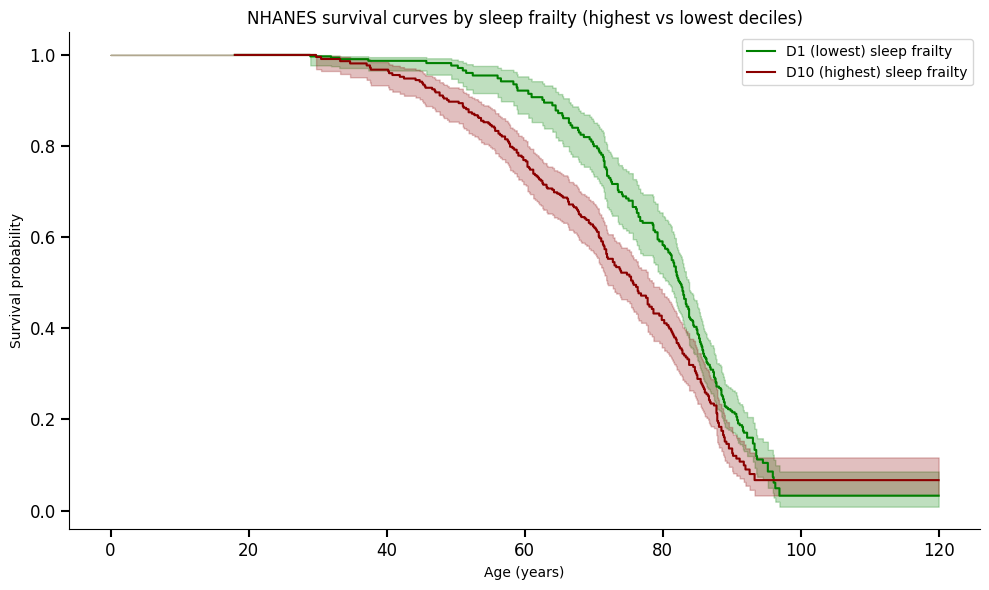

In [ ]:
# ---- 5. fit & plot sleep frailty curves ----
kmf = KaplanMeierFitter()

# Create a timeline with higher resolution to reduce approximation warnings
timeline = np.linspace(0, 120, 1000)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Clean data and create sleep frailty deciles
df_sleep_clean = df_sleep_merged.dropna(subset=["sleep_frailty", "entry_age", "exit_age"])

# Create deciles for sleep_frailty
deciles = pd.qcut(df_sleep_clean["sleep_frailty"], q=10, labels=False, duplicates='drop')
df_sleep_clean = df_sleep_clean.copy()
df_sleep_clean["sleep_frailty_decile"] = deciles

# Define colors for lowest and highest deciles
colors = ['green', 'darkred']
decile_labels = ['D1 (lowest)', 'D10 (highest)']

# Plot only the lowest (0) and highest (9) deciles
for i, d in enumerate([0, 9]):
    decile_data = df_sleep_clean[df_sleep_clean["sleep_frailty_decile"] == d]
    
    if len(decile_data) > 0:
        print(f"Decile {d+1}: {len(decile_data)} people")
        
        kmf.fit(
            durations=decile_data["exit_age"],
            event_observed=decile_data["event"],
            entry=decile_data["entry_age"],
            label=f"{decile_labels[i]} sleep frailty",
            timeline=timeline
        )
        
        kmf.plot_survival_function(ax=ax, color=colors[i])

ax.set_xlabel("Age (years)")
ax.set_ylabel("Survival probability")
ax.set_title("NHANES survival curves by sleep frailty (highest vs lowest deciles)")
ax.legend(title="")

plt.tight_layout()
plt.show()


# Physical Activity

In [18]:
df_E = pd.read_sas('nhanes/physical_activity/PAQ_E.xpt' , format = 'xport')
df_F = pd.read_sas('nhanes/physical_activity/PAQ_F.xpt' , format = 'xport')
df_G = pd.read_sas('nhanes/physical_activity/PAQ_G.xpt' , format = 'xport')
df_H = pd.read_sas('nhanes/physical_activity/PAQ_H.xpt' , format = 'xport')
df_I = pd.read_sas('nhanes/physical_activity/PAQ_I.xpt' , format = 'xport')
df_J = pd.read_sas('nhanes/physical_activity/PAQ_J.xpt' , format = 'xport')

# Convert floats to integers (rounded) while preserving NaN values
for df in [df_E, df_F, df_G, df_H, df_I, df_J]:
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].round().astype('Int64')  # Use nullable integer type to preserve NaN




# Combine all social support dataframes with standardized column names
df_activity = pd.concat([
    df_E,
    df_F,
    df_G,
    df_H,
    df_I,
    df_J
], axis=0).reset_index(drop=True)





Total participants with activity data: 52832
Participants with complete activity data: 52832
Mean MET-minutes/week: 2136.0
Median MET-minutes/week: 240.0
Participants with zero activity: 24710

Physical Activity Index Statistics:
Mean PAI: 0.363
Median PAI: 0.499
Min PAI: 0.000
Max PAI: 1.000


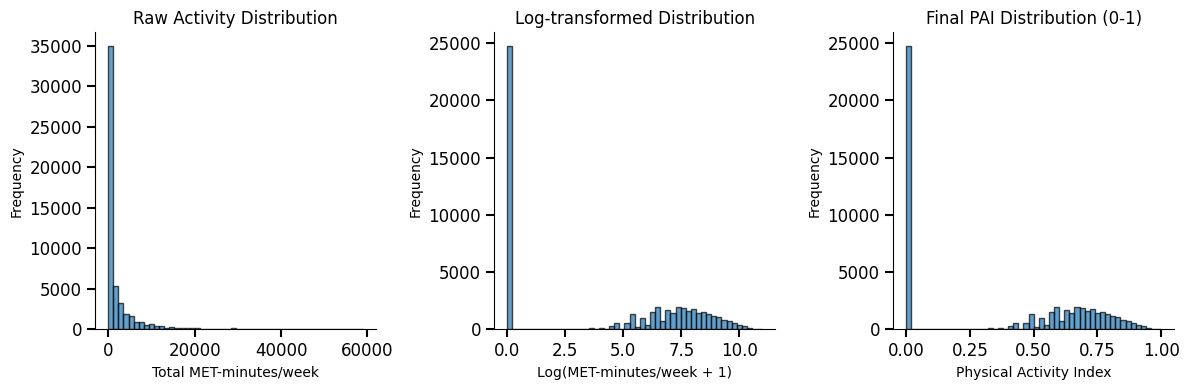

In [19]:
# ---- Physical Activity Index (PAI) Calculation ----

# Step 1: Handle missing values and create clean dataset
df_activity_clean = df_activity.copy()

# Function to handle missing values for activity variables
def clean_activity_variable(df, col_name, default_value=0):
    """Clean activity variables by replacing special codes with appropriate values"""
    if col_name in df.columns:
        # Replace refused (7, 77, 7777) and don't know (9, 99, 9999) with NaN
        df[col_name] = df[col_name].replace([7, 77, 7777, 9, 99, 9999], np.nan)
        # Fill NaN with default value (0 for yes/no questions, NaN for duration)
        if 'PAQ' in col_name:  # Yes/No questions
            df[col_name] = df[col_name].fillna(default_value)
        # For duration variables (PAD), we'll handle them differently
    return df

# Clean all relevant variables
activity_vars = ['PAQ605', 'PAQ610', 'PAD615', 'PAQ620', 'PAQ625', 'PAD630', 
                'PAQ635', 'PAQ640', 'PAD645', 'PAQ650', 'PAQ655', 'PAD660',
                'PAQ665', 'PAQ670', 'PAD675']

for var in activity_vars:
    df_activity_clean = clean_activity_variable(df_activity_clean, var)

# Step 2: Calculate MET-minutes per week for each activity domain

# Initialize total MET-minutes column
df_activity_clean['total_met_minutes_week'] = 0

# 1. Vigorous Work Activity (MET = 8.0)
vigorous_work_condition = (df_activity_clean['PAQ605'] == 1) & \
                         (df_activity_clean['PAQ610'].notna()) & \
                         (df_activity_clean['PAD615'].notna())

df_activity_clean.loc[vigorous_work_condition, 'vigorous_work_mets'] = \
    df_activity_clean.loc[vigorous_work_condition, 'PAQ610'] * \
    df_activity_clean.loc[vigorous_work_condition, 'PAD615'] * 8.0

# 2. Moderate Work Activity (MET = 4.0)
moderate_work_condition = (df_activity_clean['PAQ620'] == 1) & \
                         (df_activity_clean['PAQ625'].notna()) & \
                         (df_activity_clean['PAD630'].notna())

df_activity_clean.loc[moderate_work_condition, 'moderate_work_mets'] = \
    df_activity_clean.loc[moderate_work_condition, 'PAQ625'] * \
    df_activity_clean.loc[moderate_work_condition, 'PAD630'] * 4.0

# 3. Transportation Activity (MET = 4.0)
transport_condition = (df_activity_clean['PAQ635'] == 1) & \
                     (df_activity_clean['PAQ640'].notna()) & \
                     (df_activity_clean['PAD645'].notna())

df_activity_clean.loc[transport_condition, 'transport_mets'] = \
    df_activity_clean.loc[transport_condition, 'PAQ640'] * \
    df_activity_clean.loc[transport_condition, 'PAD645'] * 4.0

# 4. Vigorous Recreational Activity (MET = 8.0)
vigorous_rec_condition = (df_activity_clean['PAQ650'] == 1) & \
                        (df_activity_clean['PAQ655'].notna()) & \
                        (df_activity_clean['PAD660'].notna())

df_activity_clean.loc[vigorous_rec_condition, 'vigorous_rec_mets'] = \
    df_activity_clean.loc[vigorous_rec_condition, 'PAQ655'] * \
    df_activity_clean.loc[vigorous_rec_condition, 'PAD660'] * 8.0

# 5. Moderate Recreational Activity (MET = 4.0)
moderate_rec_condition = (df_activity_clean['PAQ665'] == 1) & \
                        (df_activity_clean['PAQ670'].notna()) & \
                        (df_activity_clean['PAD675'].notna())

df_activity_clean.loc[moderate_rec_condition, 'moderate_rec_mets'] = \
    df_activity_clean.loc[moderate_rec_condition, 'PAQ670'] * \
    df_activity_clean.loc[moderate_rec_condition, 'PAD675'] * 4.0

# Fill NaN values in MET columns with 0
met_columns = ['vigorous_work_mets', 'moderate_work_mets', 'transport_mets', 
               'vigorous_rec_mets', 'moderate_rec_mets']

for col in met_columns:
    if col not in df_activity_clean.columns:
        df_activity_clean[col] = 0
    else:
        df_activity_clean[col] = df_activity_clean[col].fillna(0)

# Calculate total MET-minutes per week
df_activity_clean['total_met_minutes_week'] = (
    df_activity_clean['vigorous_work_mets'] +
    df_activity_clean['moderate_work_mets'] +
    df_activity_clean['transport_mets'] +
    df_activity_clean['vigorous_rec_mets'] +
    df_activity_clean['moderate_rec_mets']
)

print(f"Total participants with activity data: {len(df_activity_clean)}")
print(f"Participants with complete activity data: {df_activity_clean['total_met_minutes_week'].notna().sum()}")
print(f"Mean MET-minutes/week: {df_activity_clean['total_met_minutes_week'].mean():.1f}")
print(f"Median MET-minutes/week: {df_activity_clean['total_met_minutes_week'].median():.1f}")
print(f"Participants with zero activity: {(df_activity_clean['total_met_minutes_week'] == 0).sum()}")

# Step 3: Normalize to create Physical Activity Index (0-1 scale)

# Log transformation to handle skewed distribution
df_activity_clean['log_total_mets'] = np.log(df_activity_clean['total_met_minutes_week'] + 1)

# Min-Max scaling to create final index
scaler = skp.MinMaxScaler()
df_activity_clean['physical_activity_index'] = scaler.fit_transform(
    df_activity_clean[['log_total_mets']]
).flatten()

print(f"\nPhysical Activity Index Statistics:")
print(f"Mean PAI: {df_activity_clean['physical_activity_index'].mean():.3f}")
print(f"Median PAI: {df_activity_clean['physical_activity_index'].median():.3f}")
print(f"Min PAI: {df_activity_clean['physical_activity_index'].min():.3f}")
print(f"Max PAI: {df_activity_clean['physical_activity_index'].max():.3f}")

# Show distribution of activity levels
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(df_activity_clean['total_met_minutes_week'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Total MET-minutes/week')
plt.ylabel('Frequency')
plt.title('Raw Activity Distribution')

plt.subplot(1, 3, 2)
plt.hist(df_activity_clean['log_total_mets'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Log(MET-minutes/week + 1)')
plt.ylabel('Frequency')
plt.title('Log-transformed Distribution')

plt.subplot(1, 3, 3)
plt.hist(df_activity_clean['physical_activity_index'], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Physical Activity Index')
plt.ylabel('Frequency')
plt.title('Final PAI Distribution (0-1)')

plt.tight_layout()
plt.show()


In [21]:
df_activity_clean = df_activity_clean.merge(core, on="SEQN", how="inner")
df_activity_clean = df_activity_clean.dropna(subset=["physical_activity_index", "entry_age", "exit_age"])

# Create a new column to hold our custom activity groups
df_activity_clean['activity_group'] = pd.NA # Initialize with a null value

# Define the 'No Activity' group
no_activity_mask = df_activity_clean['physical_activity_index'] == 0
df_activity_clean.loc[no_activity_mask, 'activity_group'] = 'No Activity'

# Define 'Moderate' and 'High' activity groups from the rest of the data
active_mask = df_activity_clean['physical_activity_index'] > 0
df_activity_clean.loc[active_mask, 'activity_group'] = pd.qcut(
    df_activity_clean.loc[active_mask, 'physical_activity_index'],
    q=3,
    labels=['Low Activity', 'Moderate Activity', 'High Activity']
)

# Now, let's see the counts for our new, more meaningful groups
print(df_activity_clean['activity_group'].value_counts())

activity_group
No Activity          12510
Low Activity          8347
Moderate Activity     7963
High Activity         7641
Name: count, dtype: int64


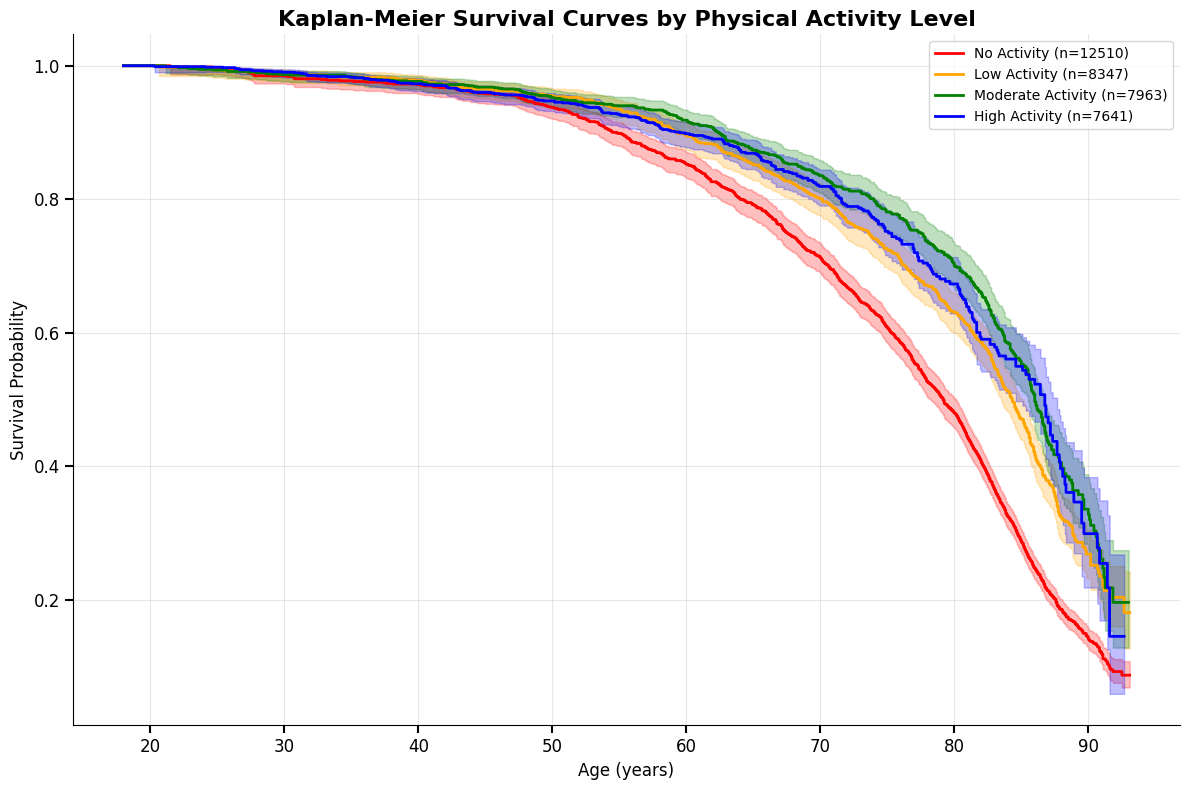


Summary statistics by activity group:
No Activity: 12510 participants, 2147.0 deaths (17.2%)
Low Activity: 8347 participants, 680.0 deaths (8.1%)
Moderate Activity: 7963 participants, 396.0 deaths (5.0%)
High Activity: 7641 participants, 280.0 deaths (3.7%)


In [22]:

# Create the Kaplan-Meier fitter
kmf = KaplanMeierFitter()

# Create the plot
plt.figure(figsize=(12, 8))

# Define colors for each group
colors = ['red', 'orange', 'green', 'blue']
activity_groups = ['No Activity', 'Low Activity', 'Moderate Activity', 'High Activity']

# Plot KM curve for each activity group
for i, group in enumerate(activity_groups):
    group_data = df_activity_clean[df_activity_clean['activity_group'] == group]
    
    if len(group_data) > 0:  # Only plot if there's data for this group
        kmf.fit(
            durations=group_data['exit_age'],
            event_observed=group_data['event'],
            entry=group_data['entry_age'],
            label=f'{group} (n={len(group_data)})'
        )
        
        kmf.plot_survival_function(color=colors[i], linewidth=2)

plt.title('Kaplan-Meier Survival Curves by Physical Activity Level', fontsize=16, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Survival Probability', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Print summary statistics for each group
print("\nSummary statistics by activity group:")
for group in activity_groups:
    group_data = df_activity_clean[df_activity_clean['activity_group'] == group]
    if len(group_data) > 0:
        events = group_data['event'].sum()
        total = len(group_data)
        print(f"{group}: {total} participants, {events} deaths ({events/total*100:.1f}%)")


# Creating Groups

In [ ]:

# Use the same default path as in nhanes_analysis.py
nhanes_data_path = '/Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/python/notebooks/thresholds, noise/nhanes/'

results = nhanes.calculate_survival_stats(nhanes_data_path, print_bootstrap=True)

with open('exposure_groups_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print('Exposure group results saved to exposure_groups_results.pkl')



# All

Value counts for diet_group:
diet_group
Fair    27271
Good    12236
Poor     2489
Name: count, dtype: int64
Value counts for INDFMMPI_group:
INDFMMPI_group
Q1 (Lowest)     7897
Q4 (Highest)    7784
Q3              7783
Q2              7770
Name: count, dtype: int64
Value counts for number_of_friends_group:
number_of_friends_group
1-5 friends     7696
6-10 friends    3203
>10 friends     2132
0 friends        637
Name: count, dtype: int64
Value counts for work_schedule:
work_schedule
Daytime work      7227
Rotating shift    1712
Night shift       1051
Name: count, dtype: int64
Value counts for sleep_hours_group:
sleep_hours_group
7-<9 hours    22189
5-<7 hours    12255
≥9 hours       5389
1-<5 hours     2092
Name: count, dtype: int64


<string>:61: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<FloatingArray>
[20160.0,   960.0,   400.0,   720.0,  7200.0, 19200.0, 28800.0,  3840.0,
   960.0,  7200.0,
 ...
   480.0,   720.0, 16800.0,  5760.0, 16800.0,   840.0,  4800.0,     0.0,
  2160.0,  5760.0]
Length: 7345, dtype: Float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
<string>:63: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<FloatingArray>
[ 3600.0,  7680.0,  4320.0,  2400.0,  2400.0,  2880.0,  3600.0,  9600.0,
   300.0,  6000.0,
 ...
  1440.0,   360.0,  8400.0,   240.0, 10080.0,  6000.0,  1200.0,  3840.0,
     0.0,  2880.0]
Length: 14491, dtype: Float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
<string>:65: FutureWarning: Setting an item of incompatible dtype is de

Value counts for activity_group:
activity_group
No Activity          12510
Low Activity          8347
Moderate Activity     7963
High Activity         7641
Name: count, dtype: int64
Value counts for drinks_per_day_group:
drinks_per_day_group
2-3 drinks/day    13257
0-1 drink/day     11241
4-5 drinks/day     3729
>5 drinks/day      3625
Name: count, dtype: int64
Value counts for sleep_frailty_decile:
sleep_frailty_decile
D1 (lowest)      1219
D10 (highest)    1177
Name: count, dtype: int64


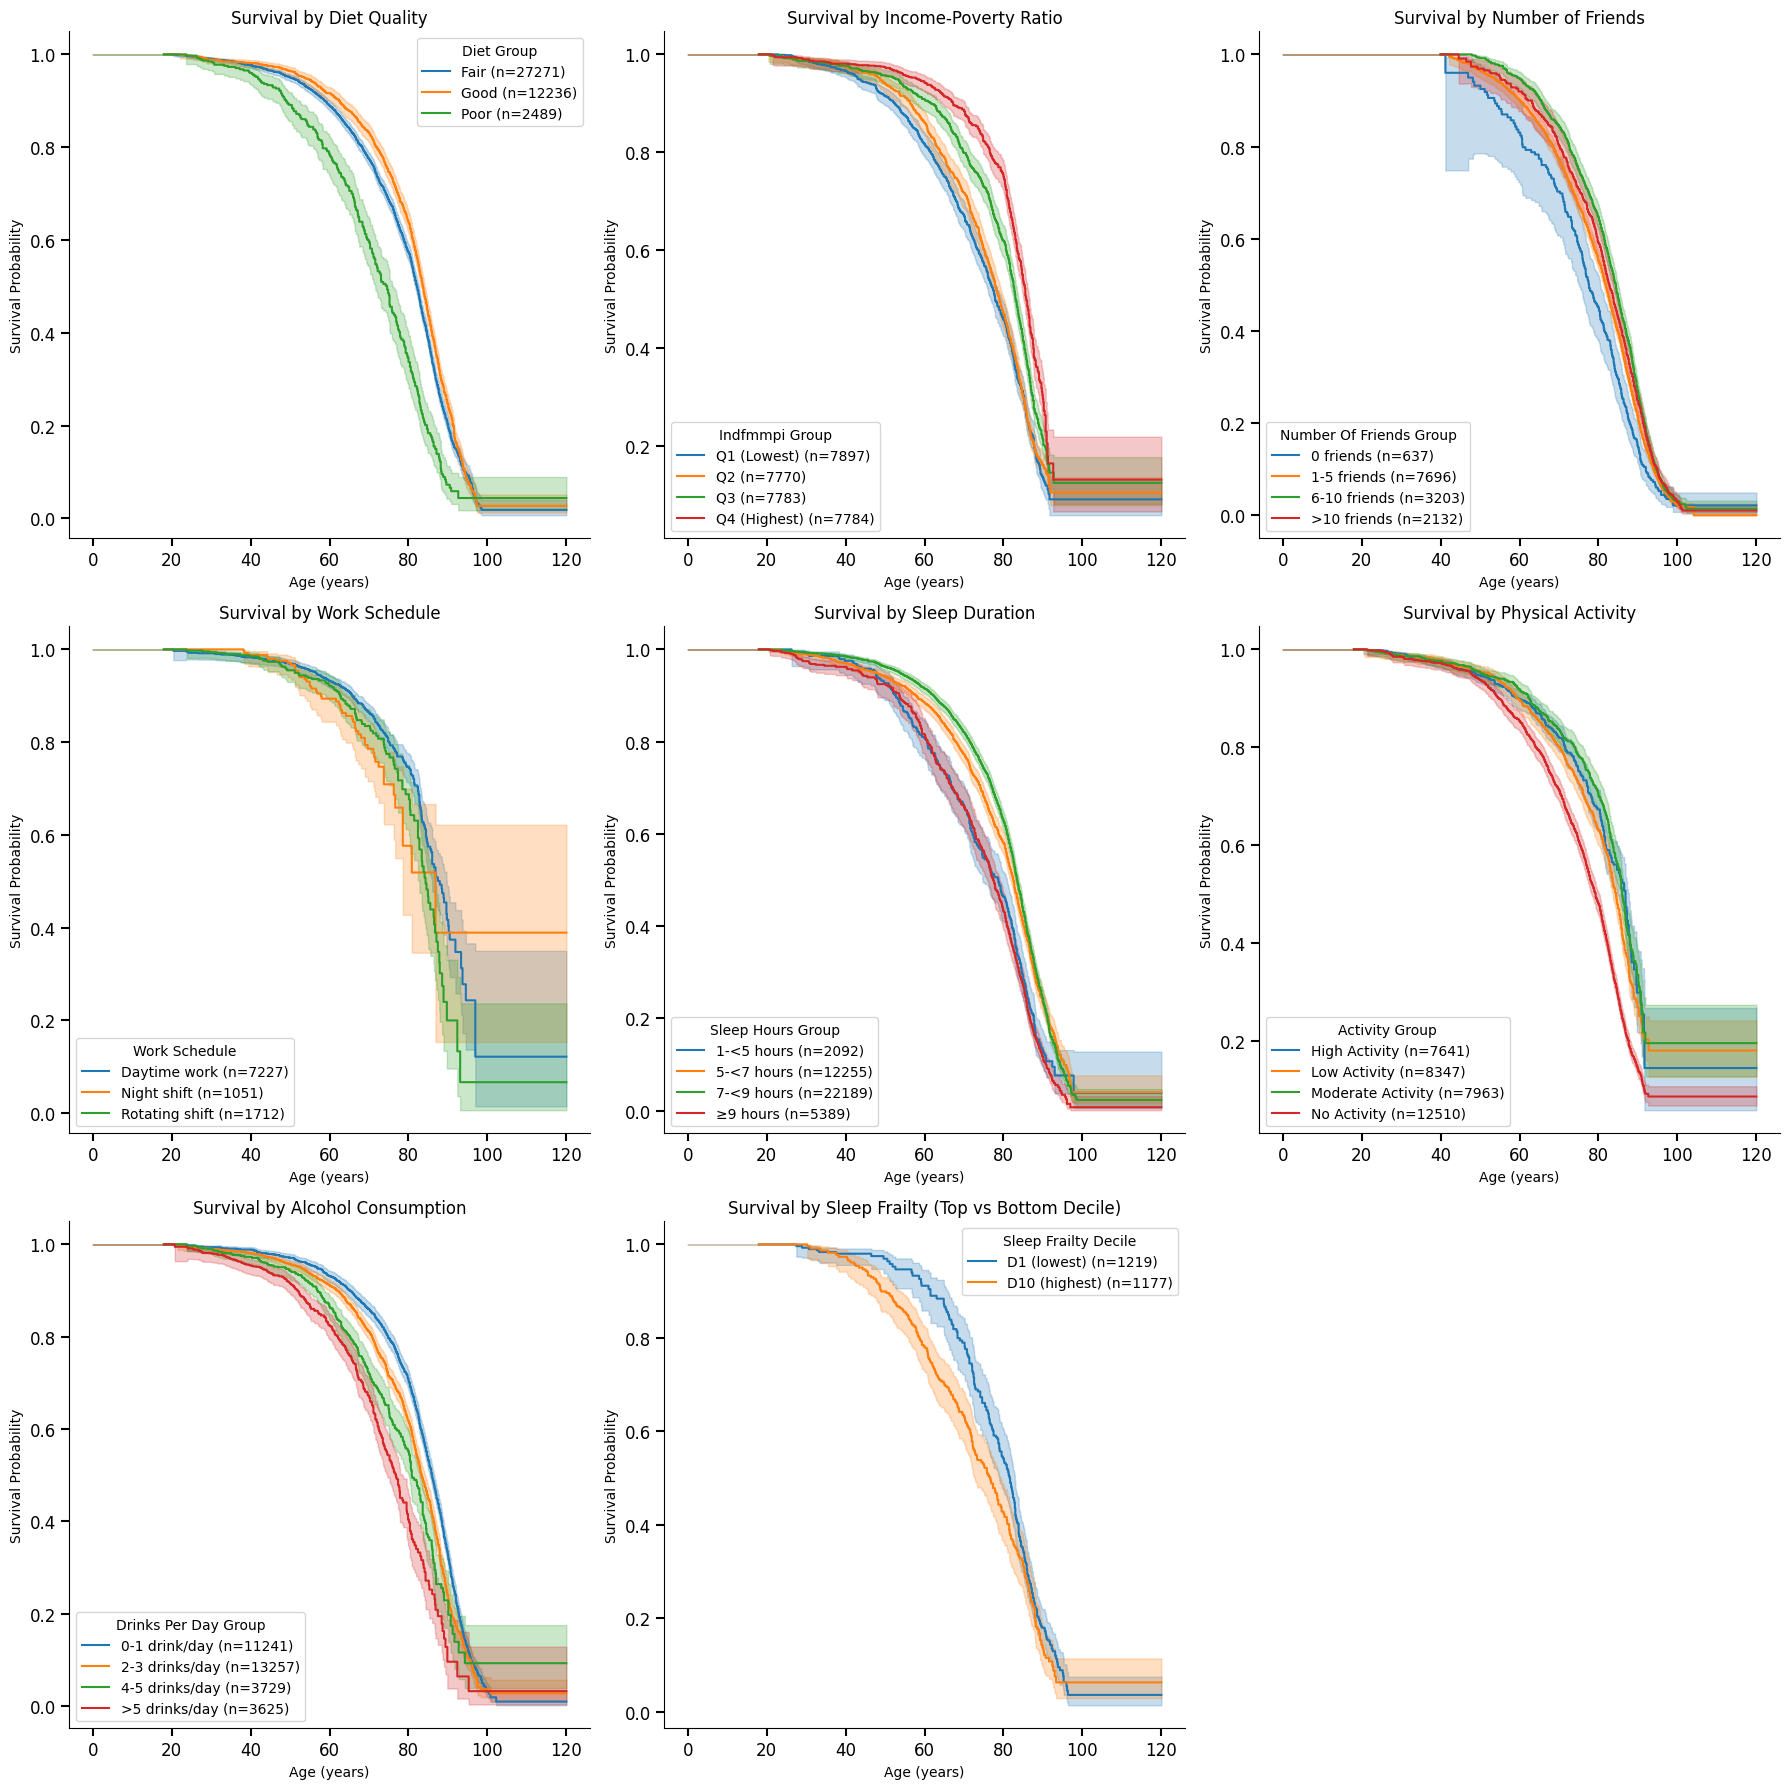

In [23]:
# Your topics
topics = ['diet', 'income', 'number_of_friends', 'work_regularity', 'sleep_duration', 'physical_activity', 'alcohol', 'sleep_frailty']

# Create a large figure with subplots
n_topics = len(topics)
n_cols = 3  # Number of columns
n_rows = int(np.ceil(n_topics / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten()  # Make it easier to index

# Plot each topic
for i, topic in enumerate(topics):
    ax = axes[i]
    
    # Get the config for this topic
    config = nhanes.TOPIC_CONFIGS[topic]
    
    # Get topic-specific dataframe
    df_topic = nhanes.get_topic_df(topic, nhanes.nhanes_data_path)
    
    # Apply grouping strategy to get the grouped data
    df_grouped, group_col = nhanes._apply_grouping_strategy(df_topic, config)
    
    # Plot survival curves for this topic
    nhanes.plot_survival_by_topic(
        df_grouped, 
        topic_column=group_col, 
        title=config['title'], 
        ax=ax
    )

# Hide any unused subplots
for i in range(n_topics, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

Value counts for diet:
diet_group
Poor    27271
Good    12236
Name: count, dtype: int64
Value counts for income:
INDFMMPI_group
Q1 (Lowest)     7897
Q4 (Highest)    7784
Q3              7783
Q2              7770
Name: count, dtype: int64
Value counts for number_of_friends:
number_of_friends_group
1+ friends    13031
0 friends       637
Name: count, dtype: int64
Value counts for work_regularity:
work_schedule
Daytime work      7227
Rotating shift    1712
Night shift       1051
Name: count, dtype: int64
Value counts for sleep_duration:
sleep_hours_group
7-<9 hours    22189
5-<7 hours    12255
≥9 hours       5389
1-<5 hours     2092
Name: count, dtype: int64
Value counts for physical_activity:
activity_group
Some Activity    23951
No Activity      12510
Name: count, dtype: int64
Value counts for alcohol:
drinks_per_day_group
2-4 drinks/day    15648
0-1 drink/day     11241
>4 drinks/day      4963
Name: count, dtype: int64
Value counts for sleep_frailty:
sleep_frailty_quartile
Q1 (lowest)  

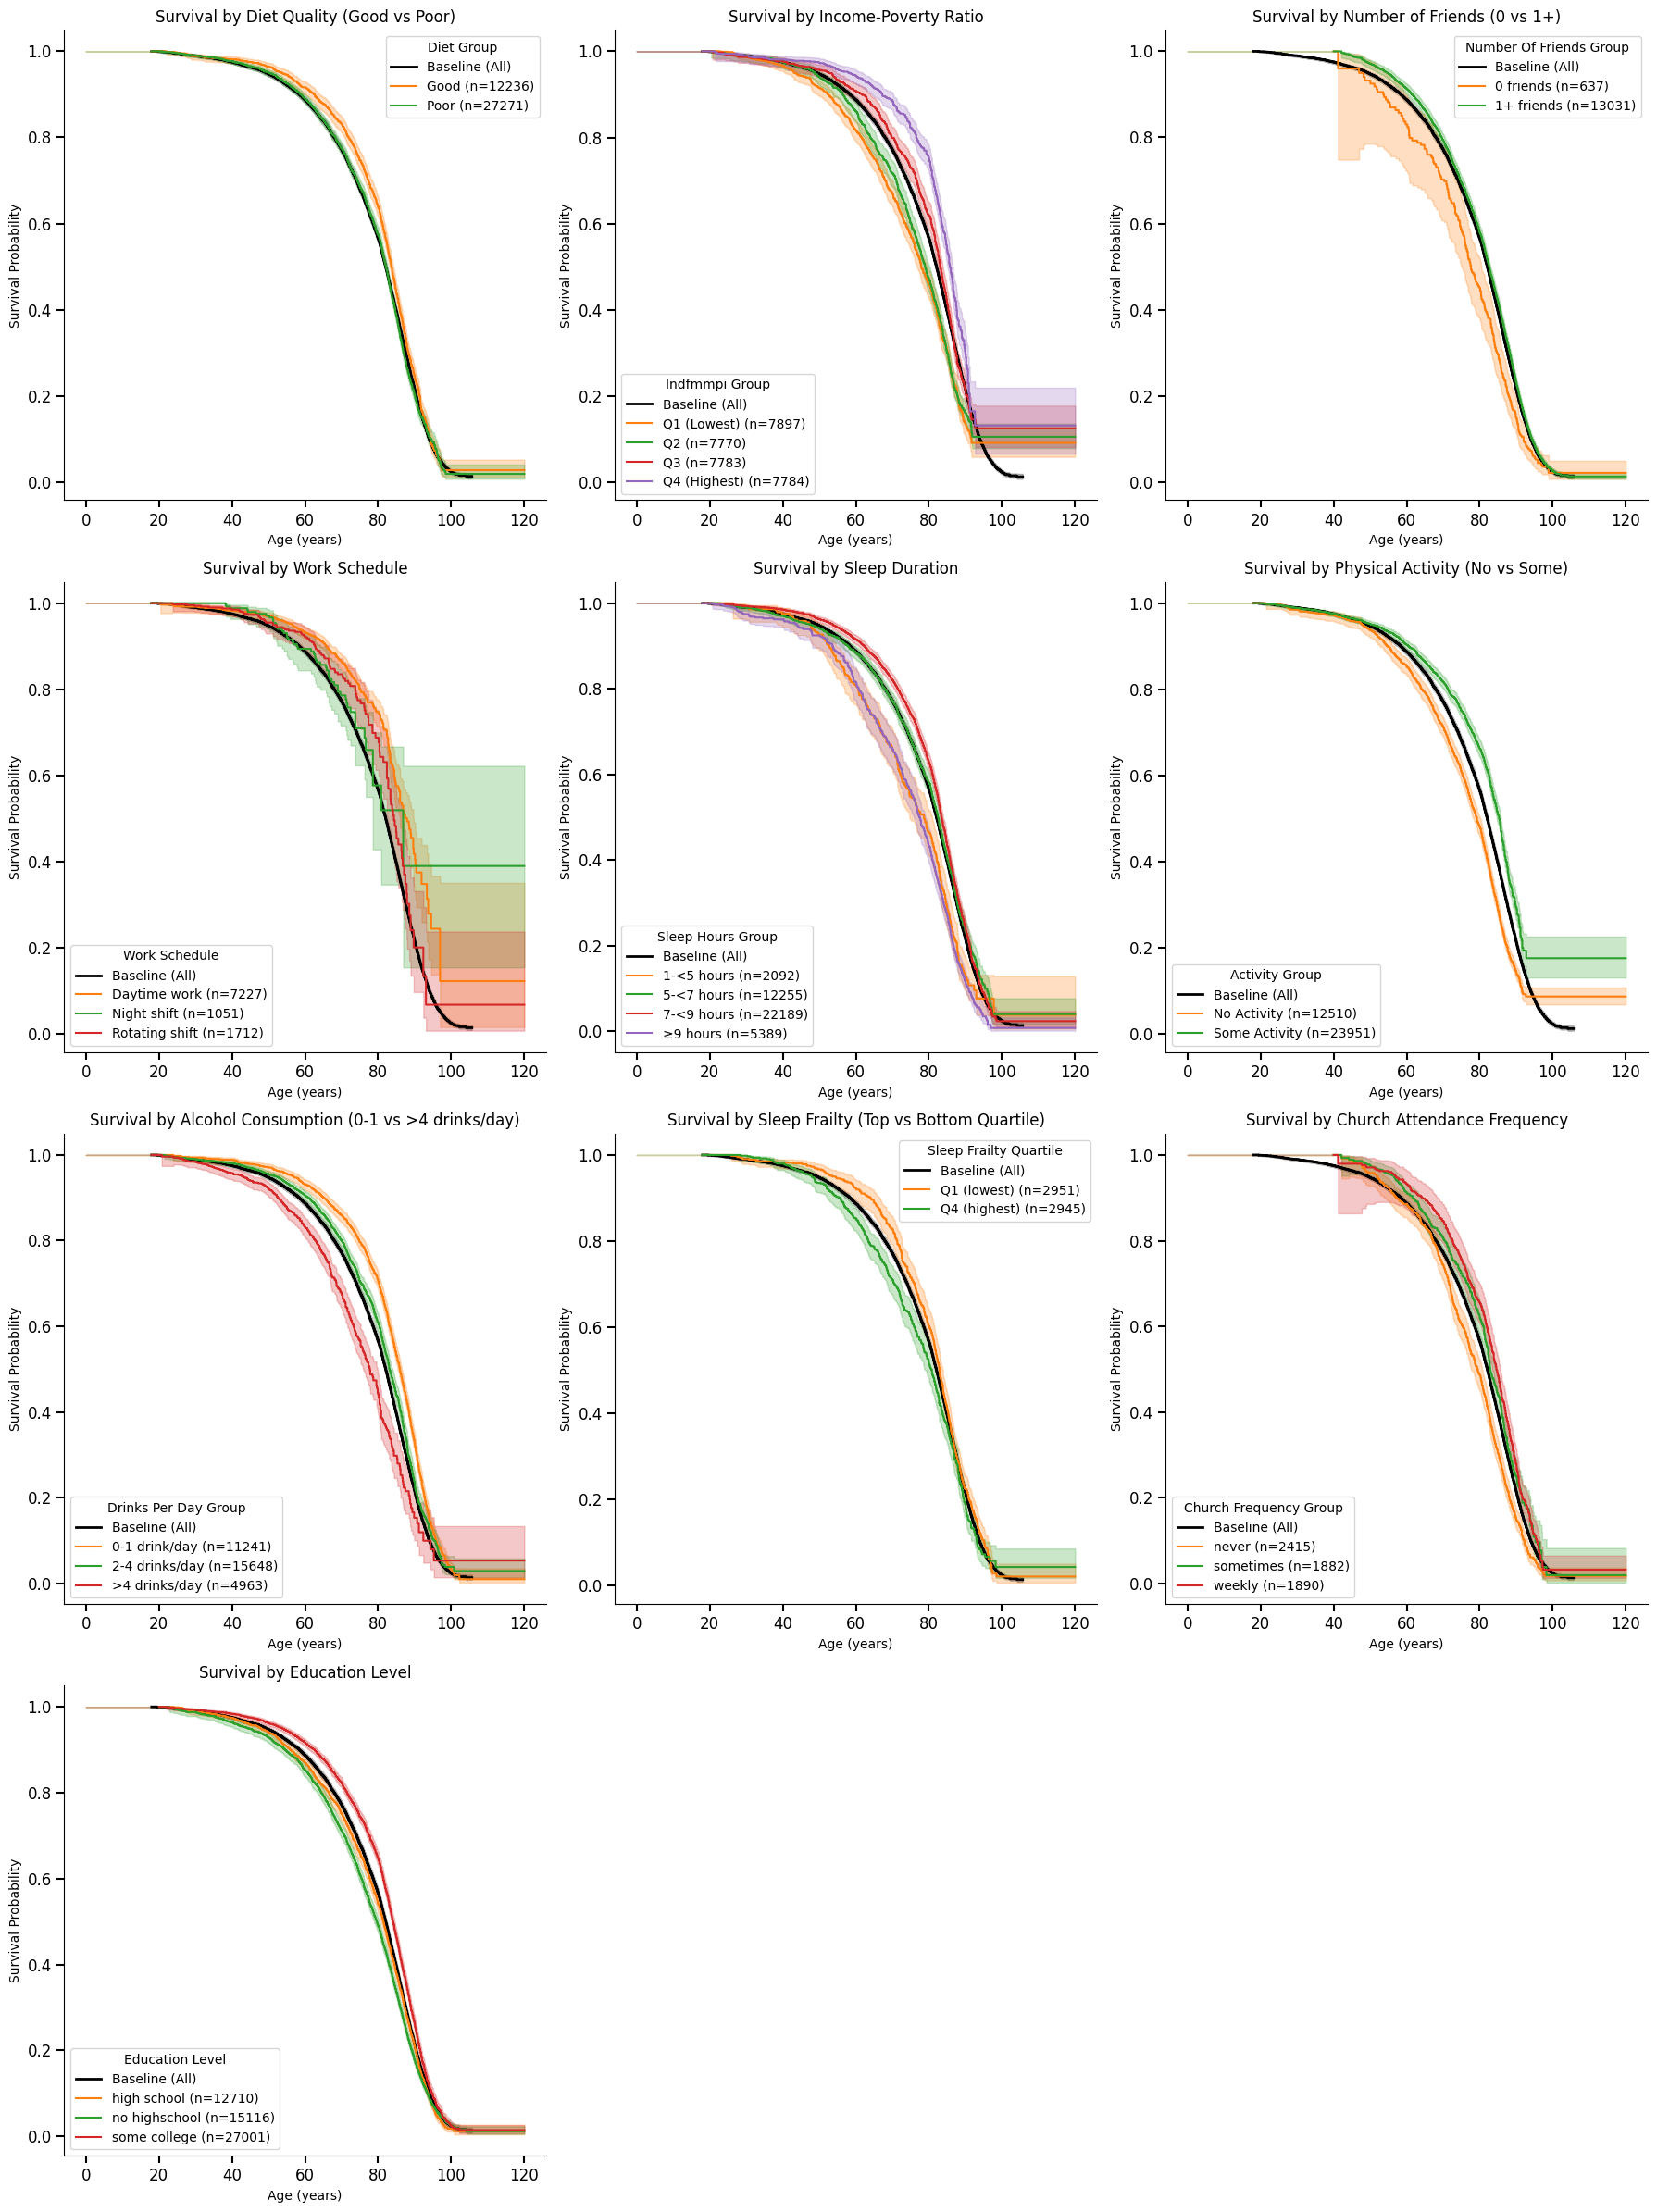

In [6]:
# Plot survival curves (updated API: plot_survival_by_topic expects topic_name, not DataFrames)
topics = ['diet', 'income', 'number_of_friends', 'work_regularity', 'sleep_duration', 'physical_activity', 'alcohol', 'sleep_frailty', 'church_frequency', 'education_level']

n_topics = len(topics)
n_cols = 3
n_rows = int(np.ceil(n_topics / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten()

for i, topic in enumerate(topics):
    ax = axes[i]
    # Use new API: only need to pass topic_name (all path/config handled inside)
    # Optionally: catch exceptions so all plots still appear even if one fails
    try:
        nhanes.plot_survival_by_topic(
            topic_name=topic,
            ax=ax
        )
    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {e}", color="red", ha="center", va="center")
        ax.set_title(f"{topic} (Error)")
        ax.axis('off')

# Hide unused axes
for i in range(n_topics, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()